In [1]:
import pandas as pd
import numpy as np
from collections import Counter

# ============================================================
# Генерация k-меров для CTRL и PSO (k=3)
# ============================================================
df_original = pd.read_csv('data_filtered.csv')

# Фильтруем только нужные состояния
df_ctrl_pso = df_original[df_original['condition'].isin(['CTRL', 'PSO'])].copy()
print(f"Образцов CTRL: {df_ctrl_pso[df_ctrl_pso['condition']=='CTRL']['sample_id'].nunique()}")
print(f"Образцов PSO: {df_ctrl_pso[df_ctrl_pso['condition']=='PSO']['sample_id'].nunique()}")

k = 3

def get_kmers(seq, k):
    """Возвращает список всех перекрывающихся k-меров из последовательности."""
    seq = str(seq)
    return [seq[i:i+k] for i in range(len(seq) - k + 1)]

# Группируем по sample_id и locus (как раньше)
all_rows = []
for (sample_id, locus), group in df_ctrl_pso.groupby(['sample_id', 'locus']):
    all_kmers = []
    for seq in group['sequence_aa']:
        all_kmers.extend(get_kmers(seq, k))
    if len(all_kmers) == 0:
        continue
    kmer_counts = Counter(all_kmers)
    total = len(all_kmers)
    for kmer, cnt in kmer_counts.items():
        all_rows.append({
            'sample_id': sample_id,
            'locus': locus,
            'kmer': kmer,
            'usage': cnt / total,
            'condition': group['condition'].iloc[0],
            'patient_id': group['patient_id'].iloc[0]
        })

df_kmers_PSO = pd.DataFrame(all_rows)
print(f"Размер таблицы: {df_kmers_PSO.shape}")
print(f"Уникальных k-меров: {df_kmers_PSO['kmer'].nunique()}")

# Сохраняем
df_kmers_PSO.to_csv("df_kmers_PSO.csv", index=False)
print("Сохранено в df_kmers_PSO.csv")

Образцов CTRL: 38
Образцов PSO: 54
Размер таблицы: (270093, 6)
Уникальных k-меров: 10216
Сохранено в df_kmers_PSO.csv


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

k = 3
# Загружаем исходный DataFrame (предполагается, что df_original уже есть)
# Но для единообразия будем использовать df_original, как раньше
all_loci = df_original['locus'].unique()
print(f"Найдены локусы: {all_loci}")

all_results = []

for locus in all_loci:
    print(f"\nОбработка локуса {locus}...")
    
    # Фильтрация по локусу и группам CTRL и PSO
    df_locus = df_original[(df_original['locus'] == locus) & (df_original['condition'].isin(['CTRL', 'PSO']))].copy()
    if df_locus.empty:
        print(f"  Нет данных для {locus} с условиями CTRL/PSO, пропускаем.")
        continue
    
    # Пулируем последовательности
    seqs_ctrl = df_locus[df_locus['condition'] == 'CTRL']['sequence_aa'].tolist()
    seqs_pso  = df_locus[df_locus['condition'] == 'PSO']['sequence_aa'].tolist()
    
    def get_all_kmers(seq_list, k):
        all_kmers = []
        for seq in seq_list:
            seq = str(seq)
            all_kmers.extend([seq[i:i+k] for i in range(len(seq)-k+1)])
        return all_kmers
    
    kmers_ctrl = get_all_kmers(seqs_ctrl, k)
    kmers_pso  = get_all_kmers(seqs_pso, k)
    total_ctrl = len(kmers_ctrl)
    total_pso  = len(kmers_pso)
    
    unique_kmers = set(kmers_ctrl).union(set(kmers_pso))
    
    for kmer in unique_kmers:
        a = kmers_ctrl.count(kmer)
        b = total_ctrl - a
        c = kmers_pso.count(kmer)
        d = total_pso - c
        table = [[a, b], [c, d]]
        odds_ratio, p_value = fisher_exact(table, alternative='two-sided')
        all_results.append({
            'locus': locus,
            'kmer': kmer,
            'ctrl_count': a,
            'ctrl_total': total_ctrl,
            'pso_count': c,
            'pso_total': total_pso,
            'odds_ratio': odds_ratio,
            'p_value': p_value
        })

# Создаём DataFrame
df_all = pd.DataFrame(all_results)
df_all['neg_log10_p'] = -np.log10(df_all['p_value'] + 1e-300)
df_all = df_all.sort_values(['locus', 'p_value']).reset_index(drop=True)

# Сохраняем результат с суффиксом _pso
df_all.to_csv("fishertest/fisher_results_all_loci_pooled_pso.csv", index=False)
print("\nГотово! Результаты сохранены в fisher_results_all_loci_pooled_pso.csv")
print(df_all.head(10))

Найдены локусы: ['IGH' 'IGK' 'IGL' 'TRA' 'TRB']

Обработка локуса IGH...

Обработка локуса IGK...

Обработка локуса IGL...

Обработка локуса TRA...

Обработка локуса TRB...

Готово! Результаты сохранены в fisher_results_all_loci_pooled_pso.csv
  locus kmer  ctrl_count  ctrl_total  pso_count  pso_total  odds_ratio  \
0   IGH  ASP         493      142998        318     201460    2.188227   
1   IGH  SPT         468      142998        297     201460    2.223982   
2   IGH  PKV         327      142998        186     201460    2.480200   
3   IGH  PTS         408      142998        265     201460    2.172413   
4   IGH  KVF         318      142998        185     201460    2.424835   
5   IGH  TSP         402      142998        278     201460    2.040154   
6   IGH  SPK         391      142998        268     201460    2.058315   
7   IGH  PLS         303      142998        198     201460    2.158393   
8   IGH  YYC         584      142998        536     201460    1.537189   
9   IGH  FPL    

После фильтрации (PSO): 2832 записей, из них уникальных CDR3: 2454
Всего значимых к-меров (PSO): 1007


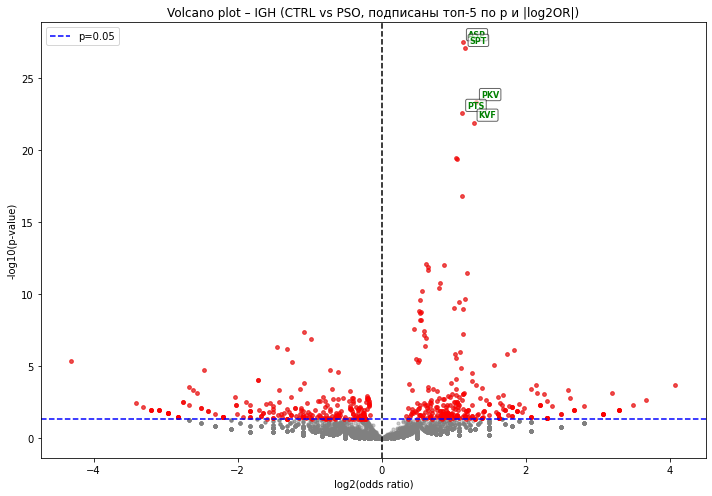

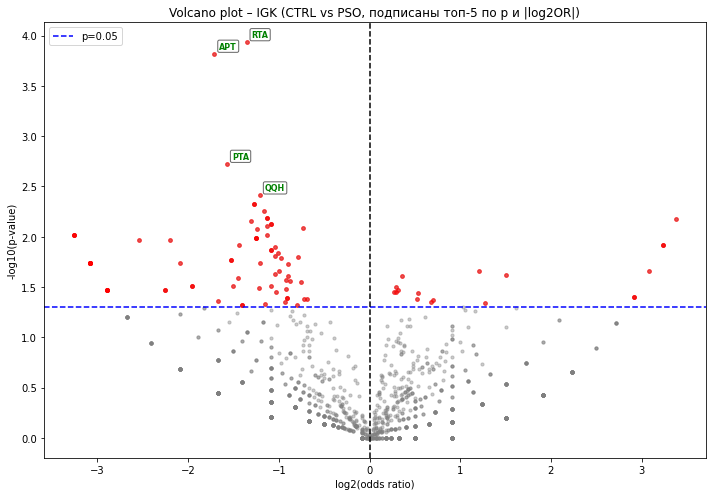

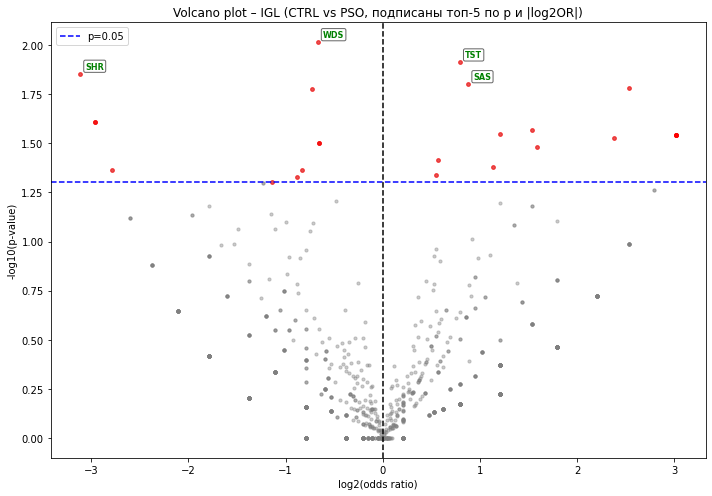

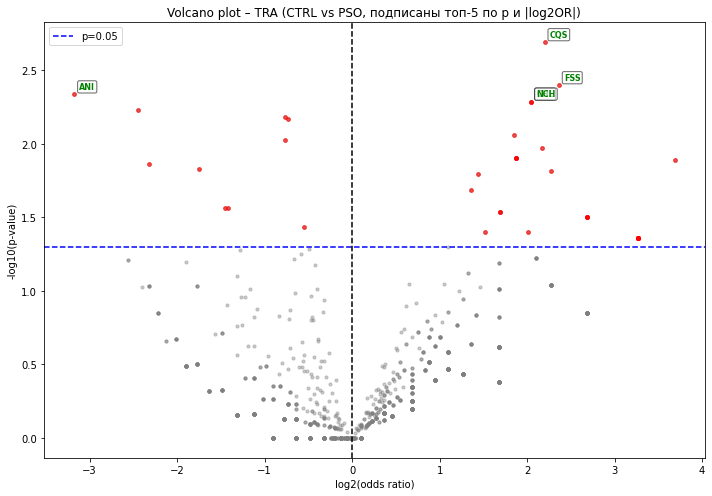

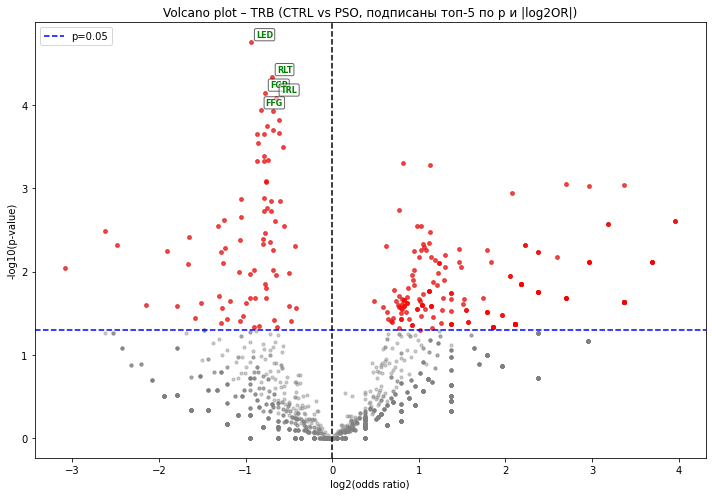


=== Анализ позиций в CDR3 (PSO) ===
Обработано 0 из 1007
Обработано 100 из 1007
Обработано 200 из 1007
Обработано 300 из 1007
Обработано 400 из 1007
Обработано 500 из 1007
Обработано 600 из 1007
Обработано 700 из 1007
Обработано 800 из 1007
Обработано 900 из 1007
Обработано 1000 из 1007
Собрано записей в CDR3 (PSO): 6974

Распределение по генным сегментам (PSO):
gene_segment
V        3167
J        2132
D         961
other     714
Name: count, dtype: int64

Топ-20 к-меров по частоте в CDR3 (PSO):
ASS: 332
QDV: 145
KQD: 144
RKQ: 143
SSL: 120
PLT: 116
GRR: 105
EQF: 102
SSP: 94
DSS: 93
SSY: 91
WDS: 88
NEQ: 85
GGS: 81
KLI: 72
SSS: 71
YFD: 66
SGG: 64
VWD: 62
EAF: 62


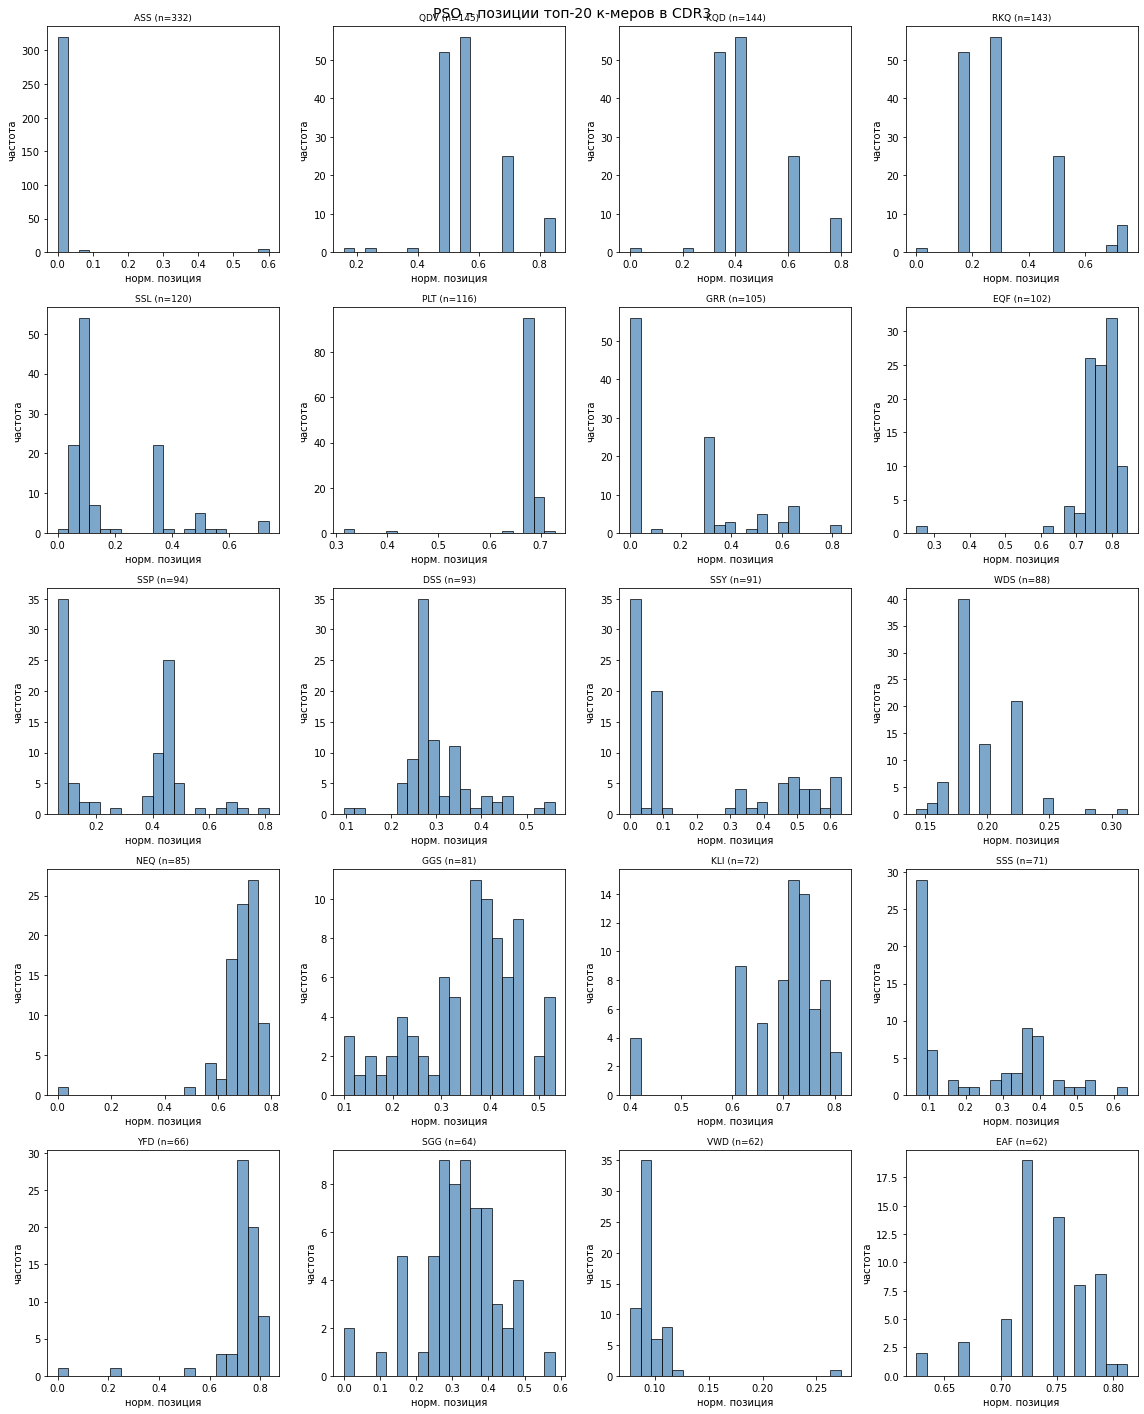

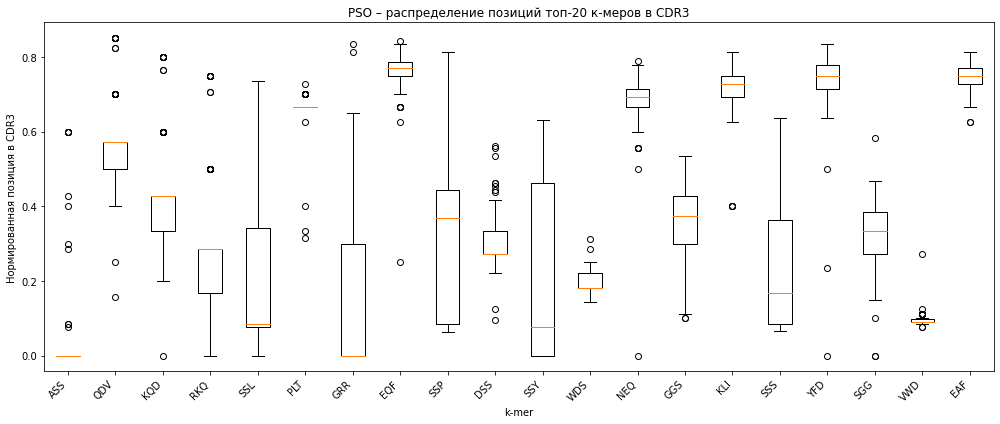

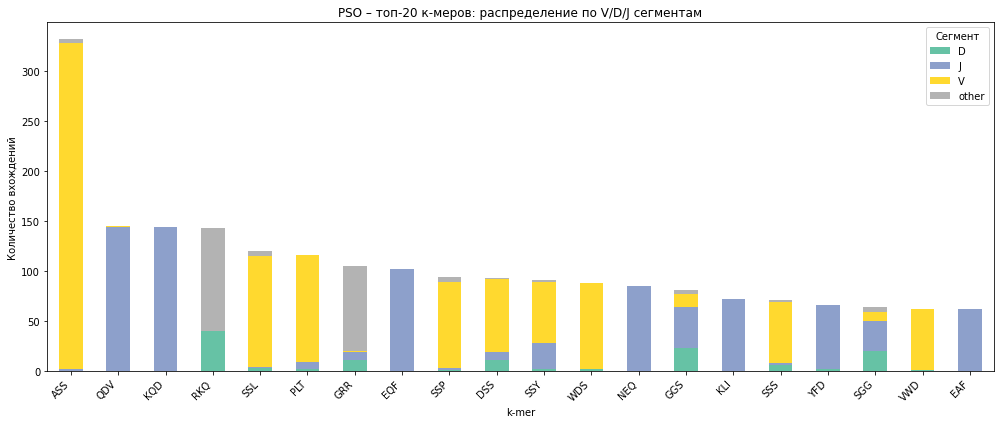


Анализ CTRL vs PSO завершён. Результаты в папках fishertest_pso и cdr3_pso/


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
import os

# Создаём папки для результатов
os.makedirs("cdr3_pso", exist_ok=True)
os.makedirs("fishertest_pso", exist_ok=True)

# ============================================================
# 1. Загрузка исходных данных
# ============================================================
df_original = pd.read_csv('data_filtered.csv')

# Фильтрация: только PSO, продуктивные, pgen_log > -40
df_pso = df_original[
    (df_original['condition'] == 'PSO') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации (PSO): {len(df_pso)} записей, из них уникальных CDR3: {df_pso['cdr3_aa'].nunique()}")

# ============================================================
# 2. Загрузка результатов Фишера для CTRL vs PSO
# ============================================================
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled_pso.csv")
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
df_fisher['significant'] = df_fisher['p_value'] < 0.05
sig_kmers = df_fisher[df_fisher['significant']]['kmer'].unique()
print(f"Всего значимых к-меров (PSO): {len(sig_kmers)}")

# ============================================================
# 3. Volcano plot с подписями топ-5 по p-value и по |log2OR|
# ============================================================
for locus in df_fisher['locus'].unique():
    sub = df_fisher[df_fisher['locus'] == locus].copy()
    sub['log2OR'] = np.log2(sub['odds_ratio'].replace(0, np.nan))
    sub['neg_log10_p'] = -np.log10(sub['p_value'] + 1e-300)
    
    sub_clean = sub.dropna(subset=['log2OR', 'neg_log10_p'])
    if sub_clean.empty:
        print(f"Нет данных для локуса {locus} после удаления NaN")
        continue
    
    top_p = sub_clean.nlargest(min(5, len(sub_clean)), 'neg_log10_p')
    top_or_indices = sub_clean['log2OR'].abs().nlargest(min(5, len(sub_clean))).index
    top_or = sub_clean.loc[top_or_indices]
    
    plt.figure(figsize=(10, 7))
    plt.scatter(sub_clean['log2OR'], sub_clean['neg_log10_p'], alpha=0.4, s=10, color='gray')
    sig = sub_clean[sub_clean['significant']]
    if not sig.empty:
        plt.scatter(sig['log2OR'], sig['neg_log10_p'], alpha=0.6, s=15, color='red')
    
    for _, row in top_p.iterrows():
        plt.annotate(row['kmer'], xy=(row['log2OR'], row['neg_log10_p']),
                     xytext=(5,5), textcoords='offset points',
                     fontsize=8, color='green', weight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    for _, row in top_or.iterrows():
        plt.annotate(row['kmer'], xy=(row['log2OR'], row['neg_log10_p']),
                     xytext=(-10,-5), textcoords='offset points',
                     fontsize=8, color='blue', weight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    
    plt.axhline(-np.log10(0.05), linestyle='--', color='blue', label='p=0.05')
    plt.axvline(0, linestyle='--', color='black')
    plt.xlabel('log2(odds ratio)')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Volcano plot – {locus} (CTRL vs PSO, подписаны топ-5 по p и |log2OR|)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"fishertest_pso/volcano_{locus}_annotated.png", dpi=150)
    plt.show()
    plt.close()

# ============================================================
# 4. Анализ позиций значимых к-меров в CDR3 (только для PSO)
# ============================================================
print("\n=== Анализ позиций в CDR3 (PSO) ===")

# Функции для перевода координат и определения сегментов
def nucleotide_to_aa_pos(nuc_pos):
    if pd.isna(nuc_pos) or nuc_pos < 0:
        return np.nan
    return (int(nuc_pos) - 1) // 3 + 1

def get_gene_segment(row, kmer_start_in_cdr3, kmer_len=3):
    required = ['cdr3_start', 'v_sequence_start', 'v_sequence_end', 
                'j_sequence_start', 'j_sequence_end']
    for col in required:
        if col not in row.index or pd.isna(row[col]):
            return 'unknown'
    cdr3_start_aa = nucleotide_to_aa_pos(row['cdr3_start'])
    v_start_aa = nucleotide_to_aa_pos(row['v_sequence_start'])
    v_end_aa = nucleotide_to_aa_pos(row['v_sequence_end'])
    j_start_aa = nucleotide_to_aa_pos(row['j_sequence_start'])
    j_end_aa = nucleotide_to_aa_pos(row['j_sequence_end'])
    if any(pd.isna(x) for x in [cdr3_start_aa, v_start_aa, v_end_aa, j_start_aa, j_end_aa]):
        return 'unknown'
    abs_start = cdr3_start_aa + kmer_start_in_cdr3
    abs_end = abs_start + kmer_len - 1
    if v_start_aa <= abs_start <= v_end_aa or v_start_aa <= abs_end <= v_end_aa:
        return 'V'
    if j_start_aa <= abs_start <= j_end_aa or j_start_aa <= abs_end <= j_end_aa:
        return 'J'
    if 'd_sequence_start' in row and 'd_sequence_end' in row:
        if not pd.isna(row['d_sequence_start']) and not pd.isna(row['d_sequence_end']):
            d_start_aa = nucleotide_to_aa_pos(row['d_sequence_start'])
            d_end_aa = nucleotide_to_aa_pos(row['d_sequence_end'])
            if not pd.isna(d_start_aa) and not pd.isna(d_end_aa):
                if d_start_aa <= abs_start <= d_end_aa or d_start_aa <= abs_end <= d_end_aa:
                    return 'D'
    return 'other'

def get_cdr3_position_info(kmer, cdr3_seq):
    if pd.isna(cdr3_seq) or not isinstance(cdr3_seq, str):
        return None
    pos = cdr3_seq.find(kmer)
    if pos == -1:
        return None
    cdr3_len = len(cdr3_seq)
    norm_pos = pos / cdr3_len if cdr3_len > 0 else np.nan
    return {'cdr3_start_index': pos, 'cdr3_len': cdr3_len, 'norm_position': norm_pos}

# Сбор данных
records = []
kmer_len = 3
total = len(sig_kmers)

for i, kmer in enumerate(sig_kmers):
    if i % 100 == 0:
        print(f"Обработано {i} из {total}")
    # Используем regex=False для буквального поиска
    mask = df_pso['cdr3_aa'].str.contains(kmer, na=False, regex=False)
    if not mask.any():
        continue
    for idx, row in df_pso[mask].iterrows():
        cdr3 = row['cdr3_aa']
        if not isinstance(cdr3, str) or len(cdr3) < kmer_len:
            continue
        start = cdr3.find(kmer)
        if start == -1:
            continue
        info = get_cdr3_position_info(kmer, cdr3)
        if info is None:
            continue
        segment = get_gene_segment(row, info['cdr3_start_index'], kmer_len)
        records.append({
            'kmer': kmer,
            'sample_id': row['sample_id'],
            'locus': row['locus'],
            'cdr3_seq': cdr3,
            'cdr3_len': info['cdr3_len'],
            'start_index': info['cdr3_start_index'],
            'norm_position': info['norm_position'],
            'gene_segment': segment
        })

df_cdr3_pso = pd.DataFrame(records)
print(f"Собрано записей в CDR3 (PSO): {len(df_cdr3_pso)}")
if len(df_cdr3_pso) > 0:
    df_cdr3_pso.to_csv("cdr3_pso/kmer_cdr3_positions_with_segments.csv", index=False)
    print("\nРаспределение по генным сегментам (PSO):")
    print(df_cdr3_pso['gene_segment'].value_counts())

# ============================================================
# 5. Сводная статистика и визуализация для топ-20 к-меров (PSO)
# ============================================================
if len(df_cdr3_pso) > 0:
    summary = df_cdr3_pso.groupby('kmer').agg(
        n_hits=('kmer', 'count'),
        mean_norm_pos=('norm_position', 'mean'),
        std_norm_pos=('norm_position', 'std'),
        most_common_segment=('gene_segment', lambda x: x.mode()[0] if len(x) > 0 else 'none')
    ).reset_index()
    summary.to_csv("cdr3_pso/kmer_cdr3_summary_with_segments.csv", index=False)
    
    top20_kmers = df_cdr3_pso['kmer'].value_counts().head(20).index
    print("\nТоп-20 к-меров по частоте в CDR3 (PSO):")
    for kmer in top20_kmers:
        print(f"{kmer}: {df_cdr3_pso[df_cdr3_pso['kmer']==kmer].shape[0]}")
    
    # Гистограммы нормированных позиций
    n_cols = 4
    n_rows = (len(top20_kmers) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    for i, kmer in enumerate(top20_kmers):
        ax = axes[i]
        sub = df_cdr3_pso[df_cdr3_pso['kmer'] == kmer]['norm_position'].dropna()
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'нет данных', ha='center', va='center')
            ax.set_title(kmer)
            continue
        ax.hist(sub, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(f'{kmer} (n={len(sub)})', fontsize=9)
        ax.set_xlabel('норм. позиция')
        ax.set_ylabel('частота')
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle('PSO – позиции топ-20 к-меров в CDR3', fontsize=14)
    plt.tight_layout()
    plt.savefig("cdr3_pso/top20_cdr3_histograms.png", dpi=150)
    plt.show()
    plt.close()
    
    # Boxplot
    plt.figure(figsize=(14, 6))
    data_for_box = []
    valid_labels = []
    for kmer in top20_kmers:
        vals = df_cdr3_pso[df_cdr3_pso['kmer'] == kmer]['norm_position'].dropna().values
        if len(vals) > 0:
            data_for_box.append(vals)
            valid_labels.append(kmer)
    if data_for_box:
        plt.boxplot(data_for_box, labels=valid_labels)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('k-mer')
        plt.ylabel('Нормированная позиция в CDR3')
        plt.title('PSO – распределение позиций топ-20 к-меров в CDR3')
        plt.tight_layout()
        plt.savefig("cdr3_pso/top20_cdr3_boxplot.png", dpi=150)
        plt.show()
    plt.close()
    
    # Stacked bar chart по сегментам
    segment_counts = df_cdr3_pso[df_cdr3_pso['kmer'].isin(top20_kmers)].groupby(['kmer', 'gene_segment']).size().unstack(fill_value=0)
    segment_counts = segment_counts.reindex(top20_kmers, fill_value=0)
    if not segment_counts.empty:
        segment_counts.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set2')
        plt.xlabel('k-mer')
        plt.ylabel('Количество вхождений')
        plt.title('PSO – топ-20 к-меров: распределение по V/D/J сегментам')
        plt.legend(title='Сегмент')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig("cdr3_pso/top20_cdr3_segments.png", dpi=150)
        plt.show()
    plt.close()

print("\nАнализ CTRL vs PSO завершён. Результаты в папках fishertest_pso и cdr3_pso/")

In [5]:
# Пример для к-мера с наибольшим числом вхождений
top_kmer = summary.nlargest(1, 'n_hits')['kmer'].iloc[0]
print(f"\nПример для к-мера: {top_kmer}")
sub = df_cdr3_pso[df_cdr3_pso['kmer'] == top_kmer]
print(f"  Всего вхождений: {len(sub)}")
print("  Первые 5 записей:")
print(sub[['cdr3_seq', 'start_index', 'cdr3_len', 'norm_position']].head())


Пример для к-мера: ASS
  Всего вхождений: 332
  Первые 5 записей:
             cdr3_seq  start_index  cdr3_len  norm_position
1439     ASSFVGSTGELF            0        12            0.0
1440      ASSRTVNTEAF            0        11            0.0
1441  ASSSGLAGGPGNEQF            0        15            0.0
1442  ASSYSGQGAMNYGYT            0        15            0.0
1443     ASSTRPQQGAQY            0        12            0.0


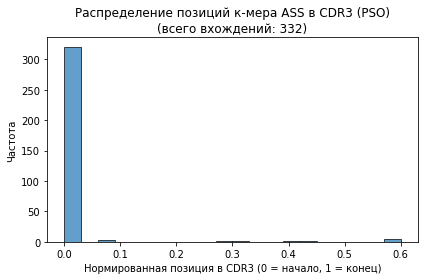

In [6]:
# Визуализация распределения для этого к-мера
plt.figure(figsize=(6,4))
plt.hist(sub['norm_position'], bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Нормированная позиция в CDR3 (0 = начало, 1 = конец)')
plt.ylabel('Частота')
plt.title(f'Распределение позиций к-мера {top_kmer} в CDR3 (PSO)\n(всего вхождений: {len(sub)})')
plt.tight_layout()
plt.savefig(f"cdr3_pso/example_{top_kmer}_cdr3_position.png", dpi=150)
plt.show()
plt.close()

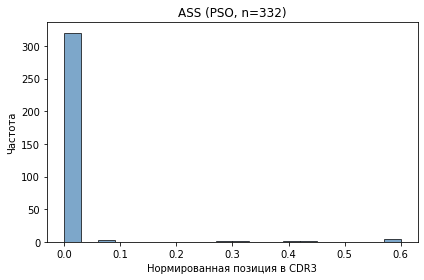

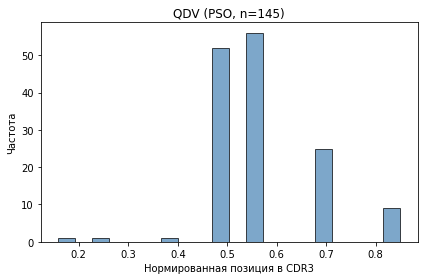

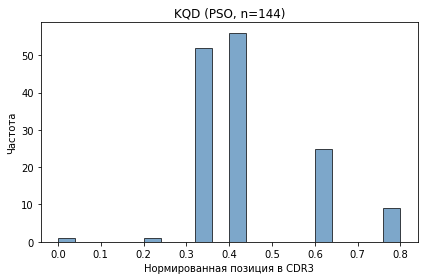

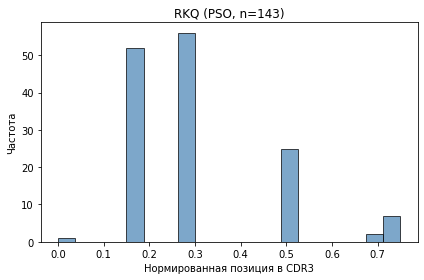

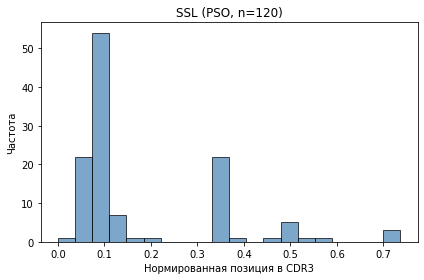

In [7]:
# Топ-5 к-меров по частоте в CDR3
top5_kmers = summary.nlargest(5, 'n_hits')['kmer'].values
for kmer in top5_kmers:
    sub = df_cdr3_pso[df_cdr3_pso['kmer'] == kmer]
    if sub.empty:
        continue
    plt.figure(figsize=(6,4))
    plt.hist(sub['norm_position'], bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Нормированная позиция в CDR3')
    plt.ylabel('Частота')
    plt.title(f'{kmer} (PSO, n={len(sub)})')
    plt.tight_layout()
    plt.savefig(f"cdr3_pso/cdr3_position_{kmer}.png", dpi=150)
    plt.show()
    plt.close()

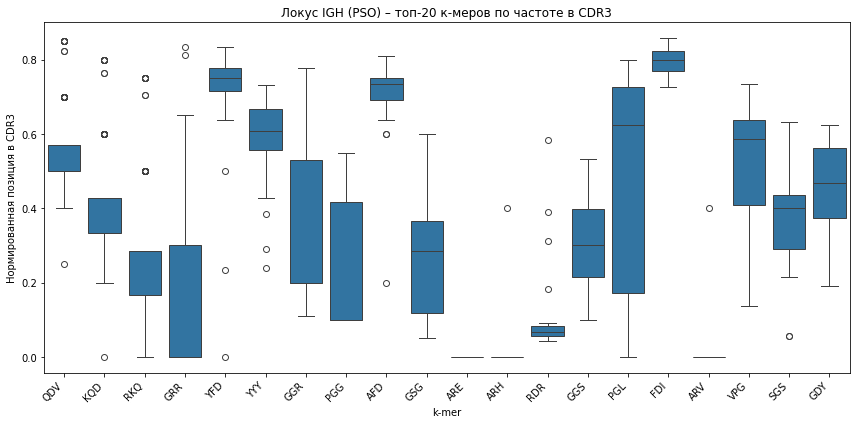

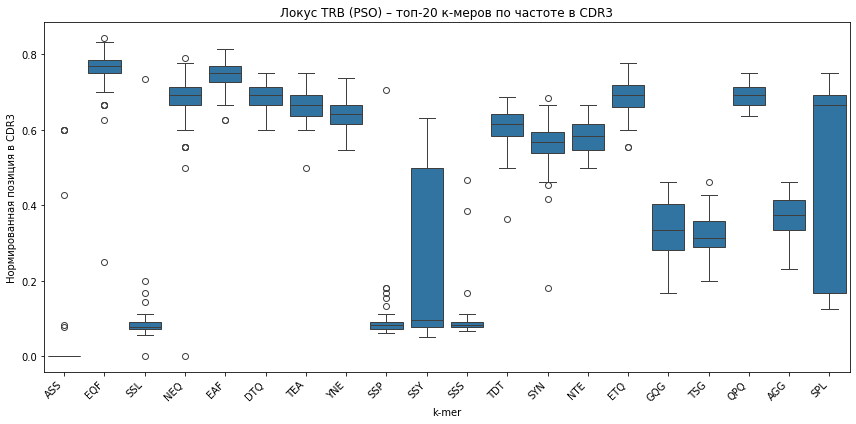

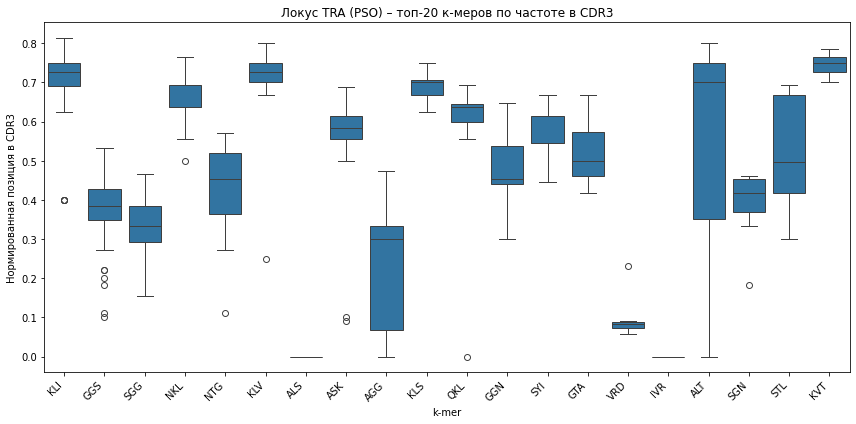

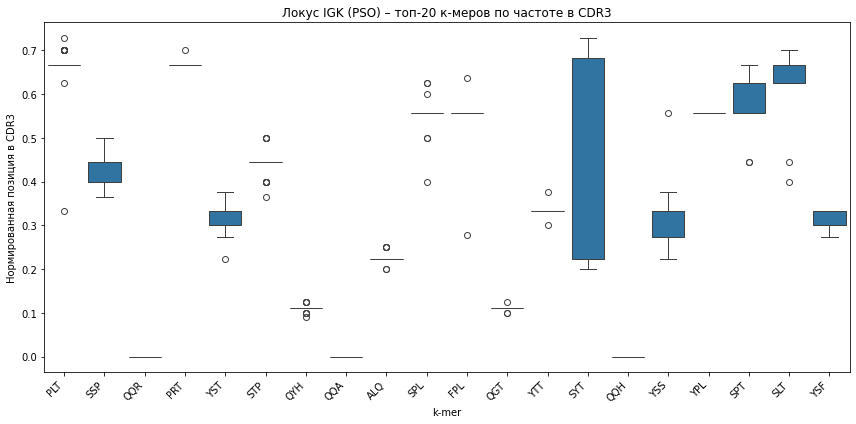

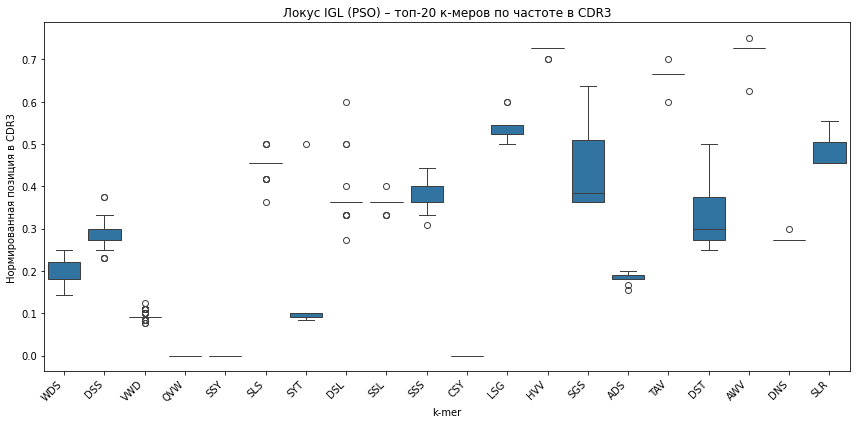

In [8]:
# Boxplot по локусам (все к-меры в данном локусе - может быть много, лучше ограничить)
for locus in df_cdr3_pso['locus'].unique():
    sub = df_cdr3_pso[df_cdr3_pso['locus'] == locus]
    if sub.empty:
        continue
    # Топ-20 к-меров по частоте в этом локусе
    top20 = sub['kmer'].value_counts().head(20).index
    sub_top = sub[sub['kmer'].isin(top20)]
    if sub_top.empty:
        continue
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=sub_top, x='kmer', y='norm_position', order=top20)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('k-mer')
    plt.ylabel('Нормированная позиция в CDR3')
    plt.title(f'Локус {locus} (PSO) – топ-20 к-меров по частоте в CDR3')
    plt.tight_layout()
    plt.savefig(f"cdr3_pso/cdr3_positions_{locus}_top20_boxplot.png", dpi=150)
    plt.show()
    plt.close()

In [10]:
summary = df_cdr3_pso.groupby('kmer').agg(
    n_hits=('kmer', 'count'),
    mean_norm_pos=('norm_position', 'mean'),
    std_norm_pos=('norm_position', 'std'),
    most_common_segment=('gene_segment', lambda x: x.mode()[0] if len(x) > 0 else 'none')
).reset_index()
summary

,kmer,n_hits,mean_norm_pos,std_norm_pos,most_common_segment
0,AAD,5,0.186667,0.272438,V
1,AAE,5,0.194118,0.266010,V
2,AAT,8,0.269118,0.302412,V
3,AAV,9,0.603989,0.107112,D
4,AAY,5,0.326786,0.299580,J
...,...,...,...,...,...
755,YVV,4,0.588068,0.196853,J
756,YWG,1,0.375000,NaN,D
757,YYC,2,0.486742,0.275879,J
758,YYD,19,0.352779,0.159429,D


После фильтрации (PSO): 2832 записей
Локусы: ['IGH' 'IGK' 'TRA' 'TRB' 'IGL']
Всего значимых к-меров (PSO): 1070

Обработка локуса: IGH (PSO)
  Записей в локусе: 965
  Значимых к-меров в локусе: 564
  Собрано записей в CDR3: 1770

  Распределение по генным сегментам для IGH:
gene_segment
J        575
other    492
D        469
V        234
Name: count, dtype: int64
  Топ-20 к-меров для IGH: ['QDV', 'KQD', 'RKQ', 'GRR', 'YFD']...


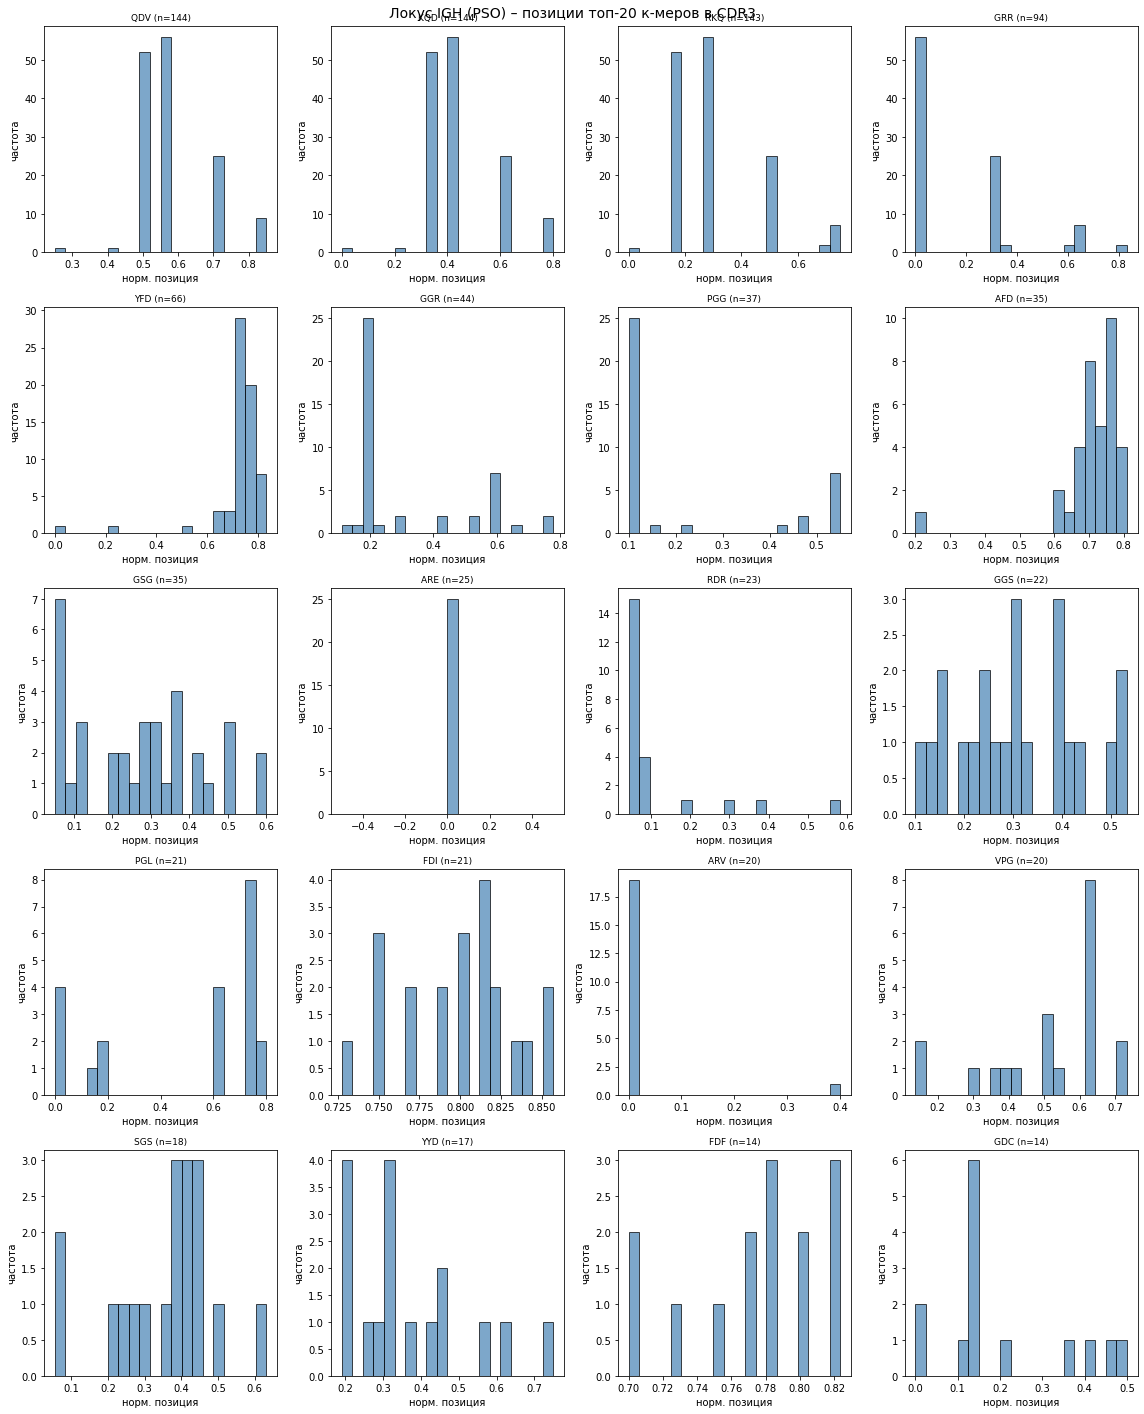

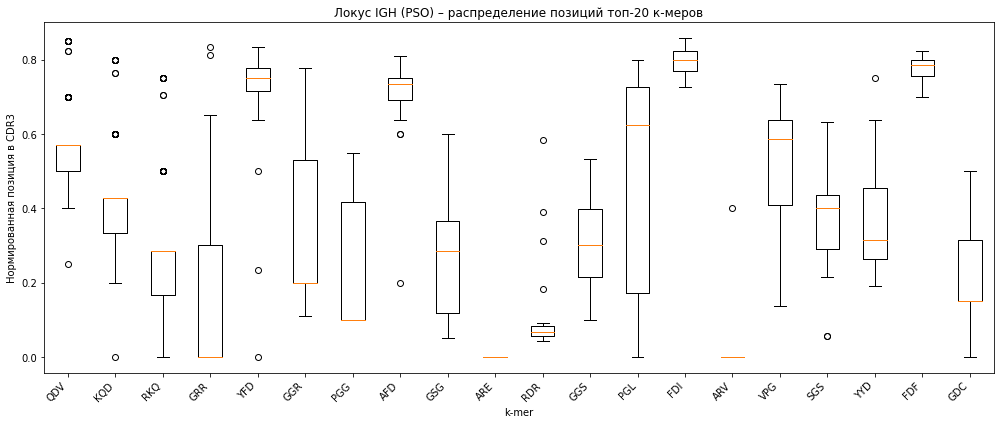

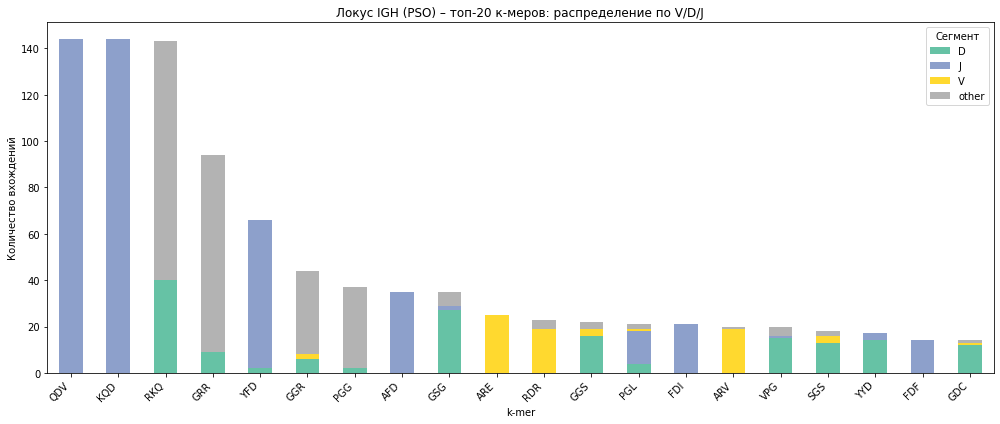


Обработка локуса: IGK (PSO)
  Записей в локусе: 600
  Значимых к-меров в локусе: 116
  Собрано записей в CDR3: 251

  Распределение по генным сегментам для IGK:
gene_segment
V        242
J          7
other      2
Name: count, dtype: int64
  Топ-20 к-меров для IGK: ['SSP', 'YST', 'STP', 'QYH', 'QQH']...


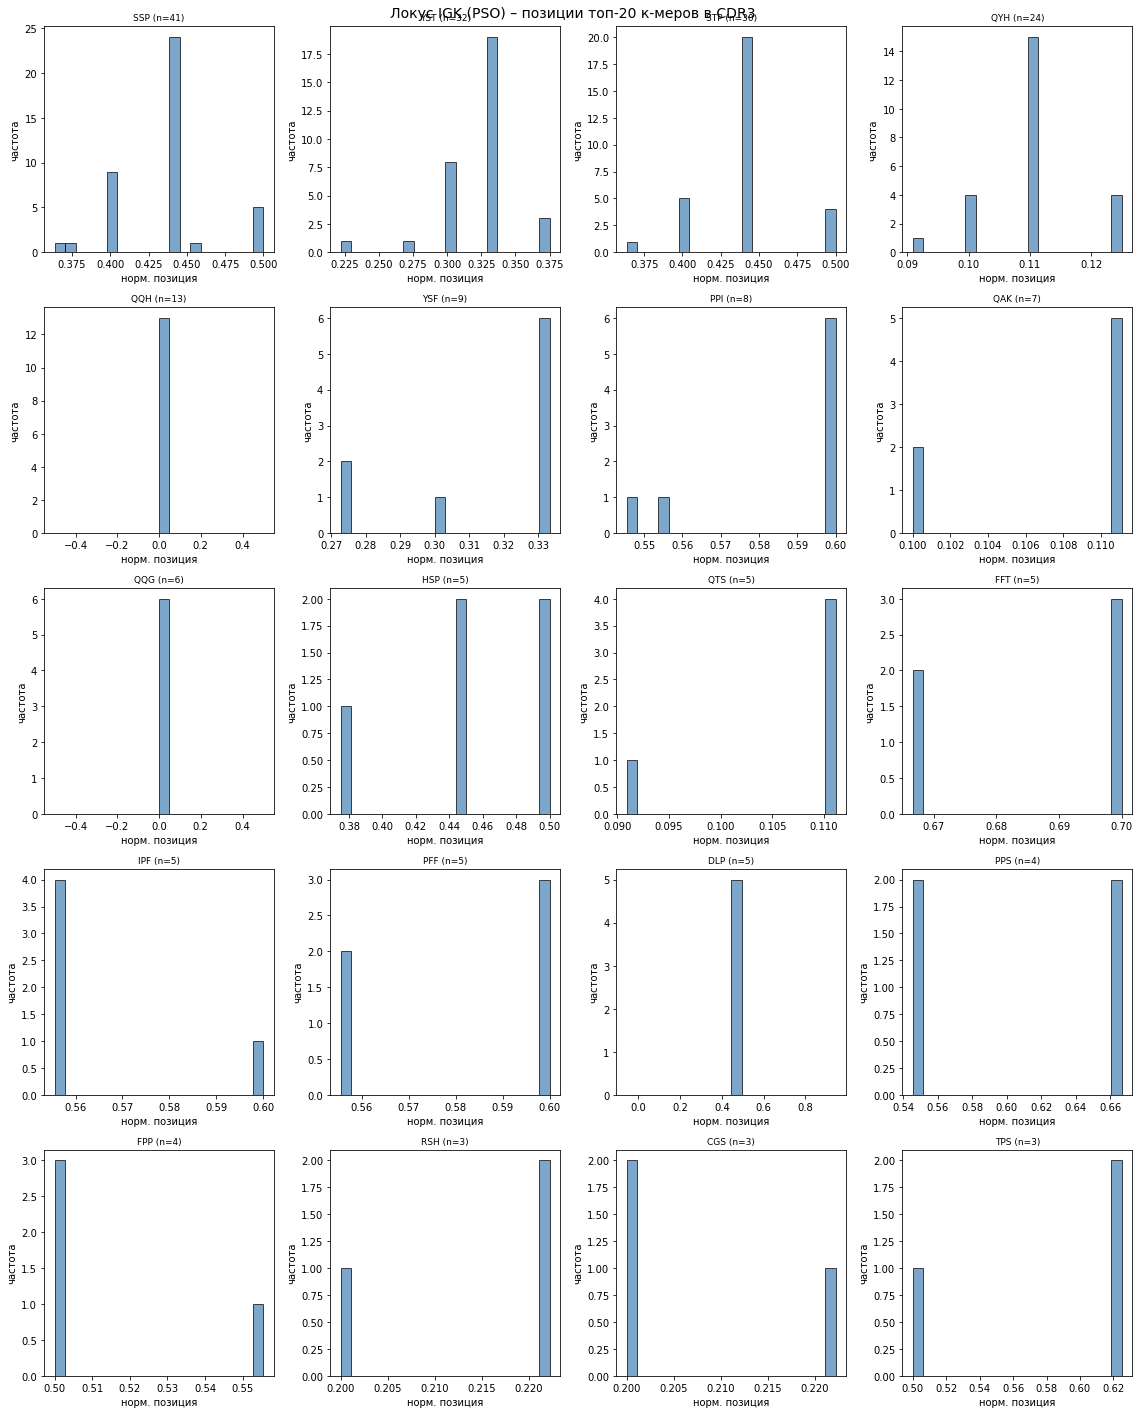

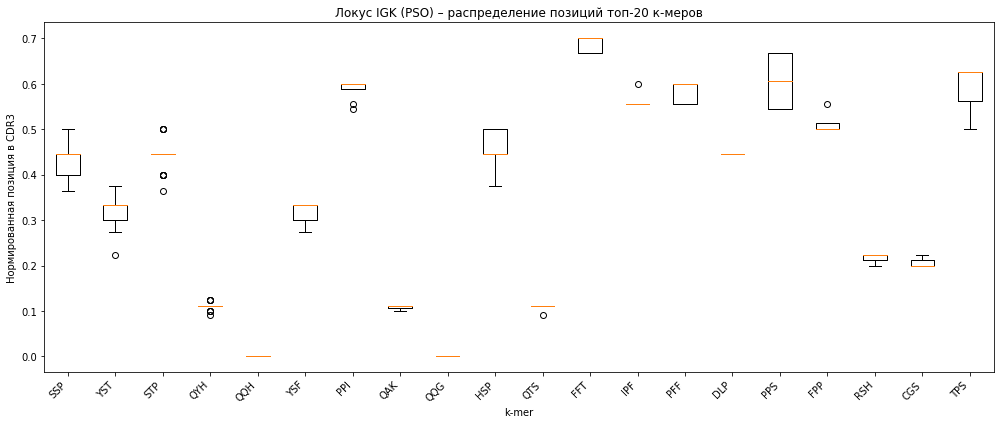

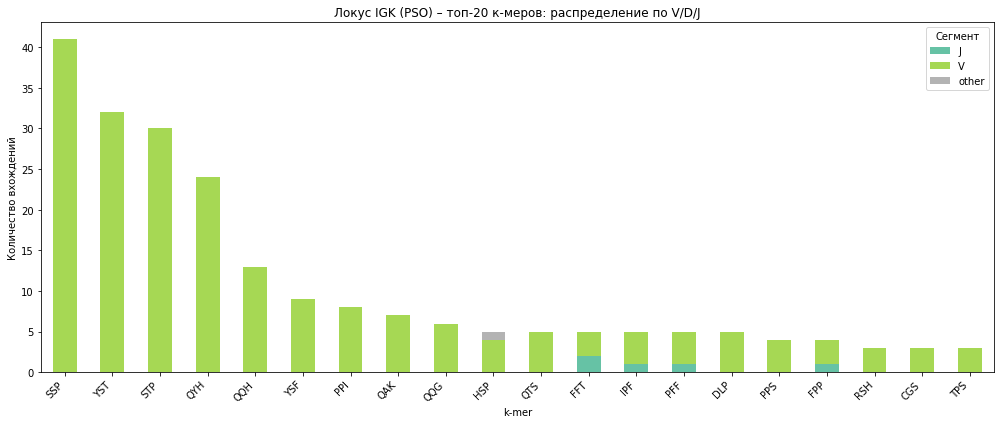


Обработка локуса: TRA (PSO)
  Записей в локусе: 396
  Значимых к-меров в локусе: 46
  Собрано записей в CDR3: 54

  Распределение по генным сегментам для TRA:
gene_segment
J        27
V        26
other     1
Name: count, dtype: int64
  Топ-20 к-меров для TRA: ['VRD', 'SNY', 'AMR', 'NLF', 'VSD']...


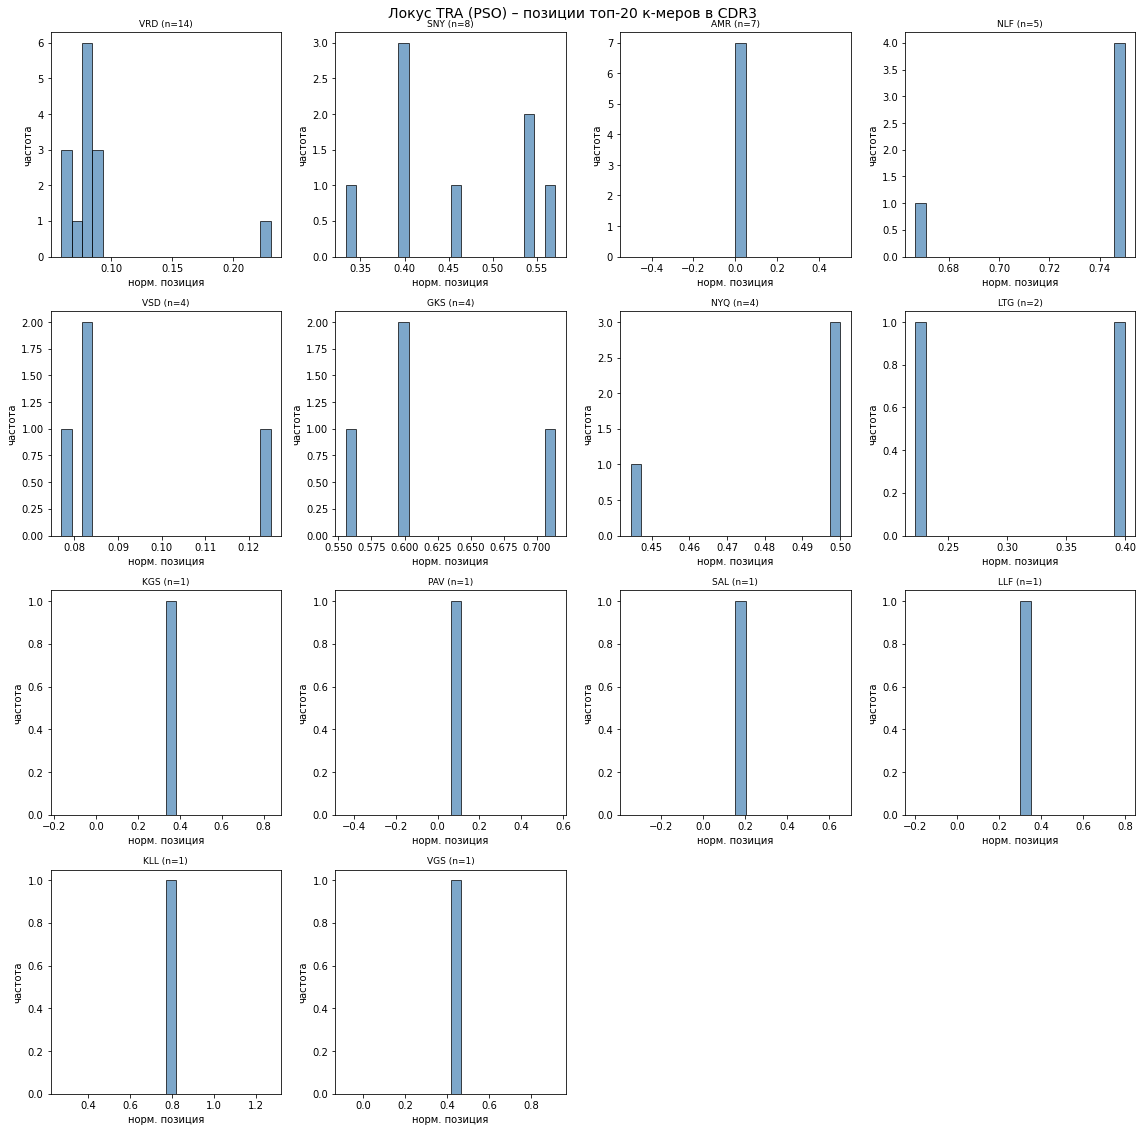

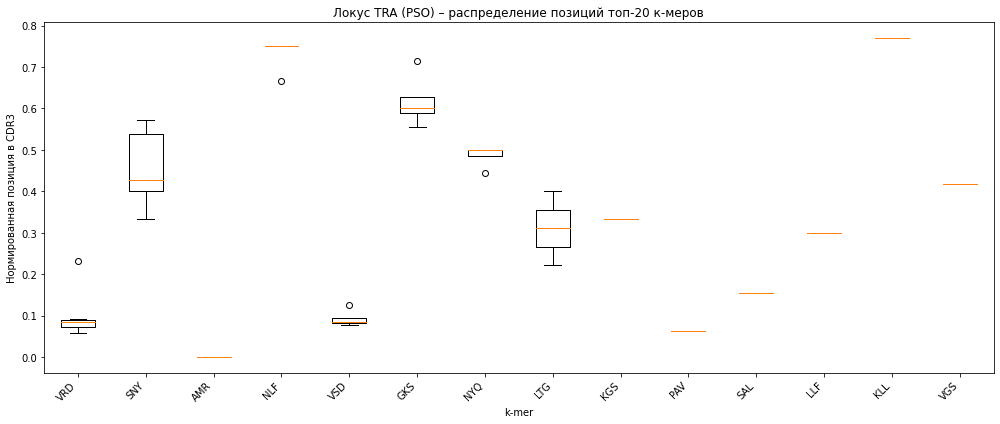

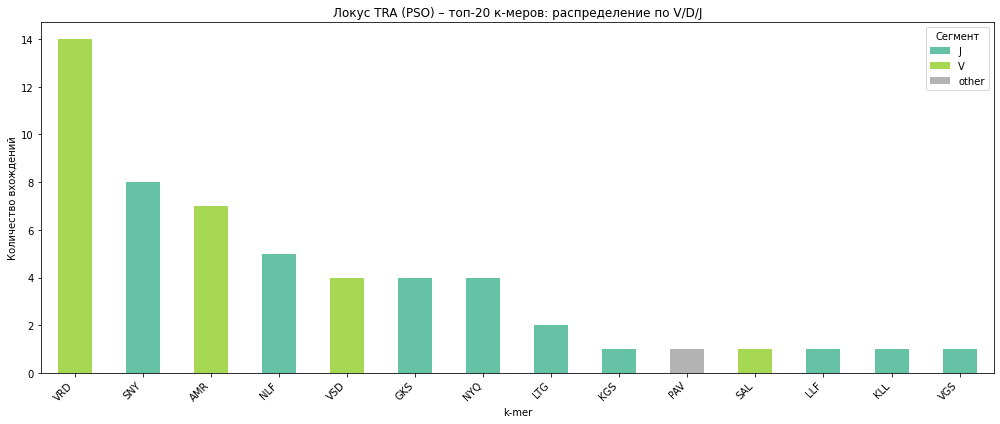


Обработка локуса: TRB (PSO)
  Записей в локусе: 576
  Значимых к-меров в локусе: 305
  Собрано записей в CDR3: 1042

  Распределение по генным сегментам для TRB:
gene_segment
J        486
V        454
D         68
other     34
Name: count, dtype: int64
  Топ-20 к-меров для TRB: ['ASS', 'EQF', 'NEQ', 'EAF', 'DTQ']...


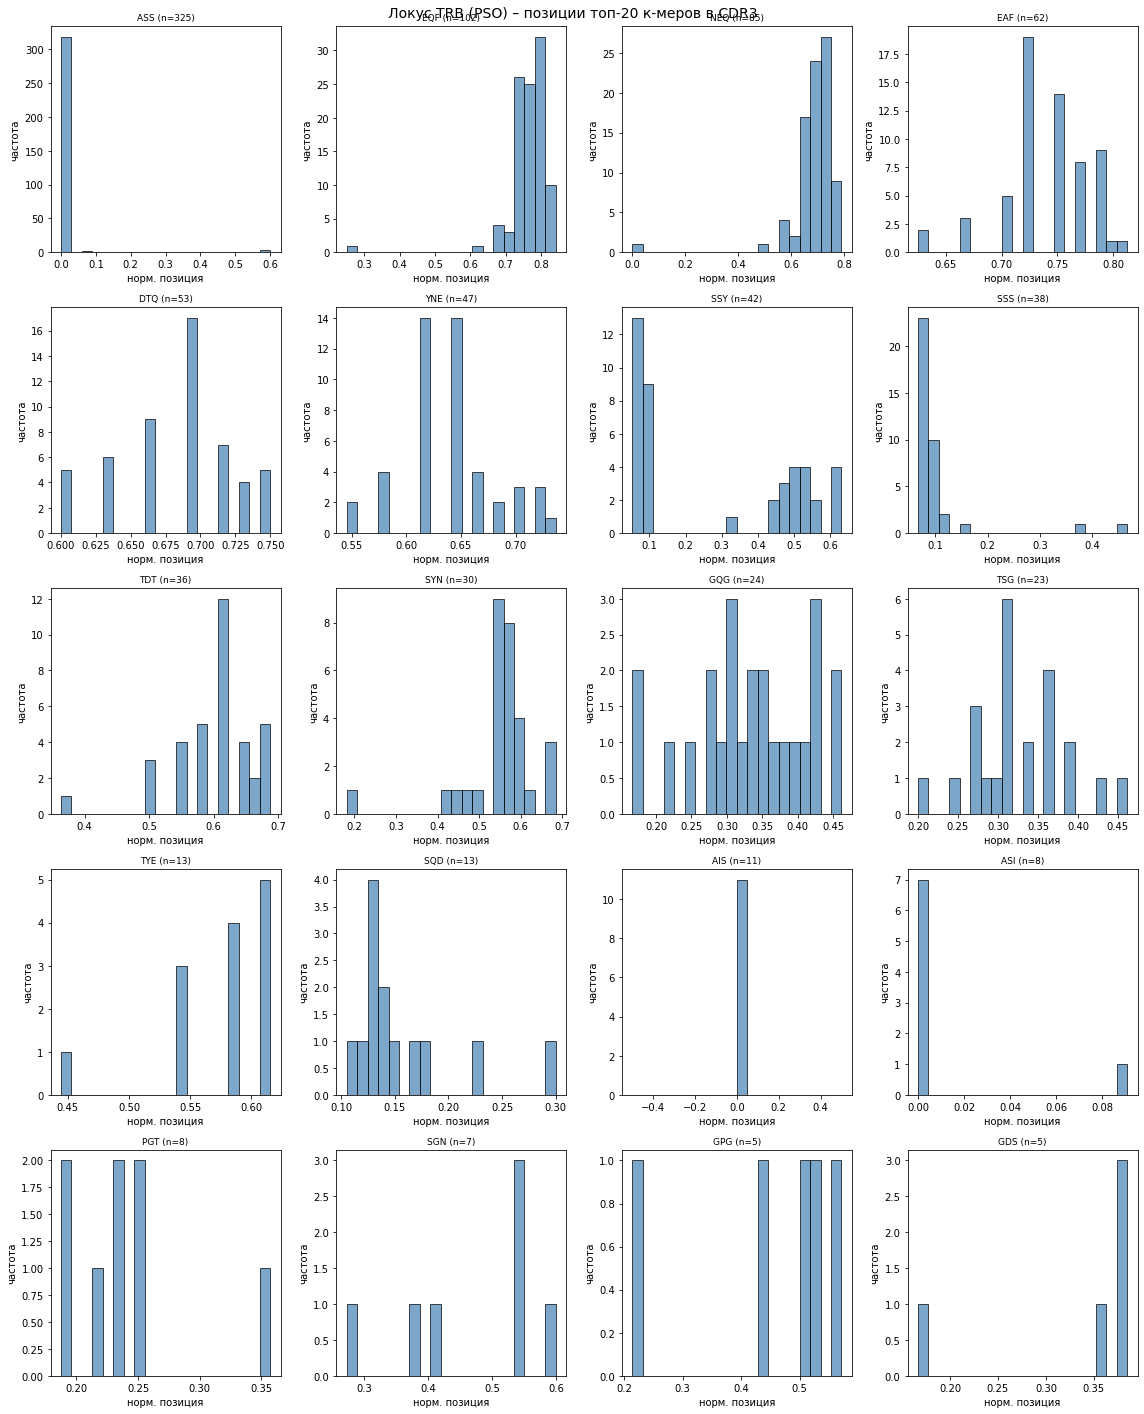

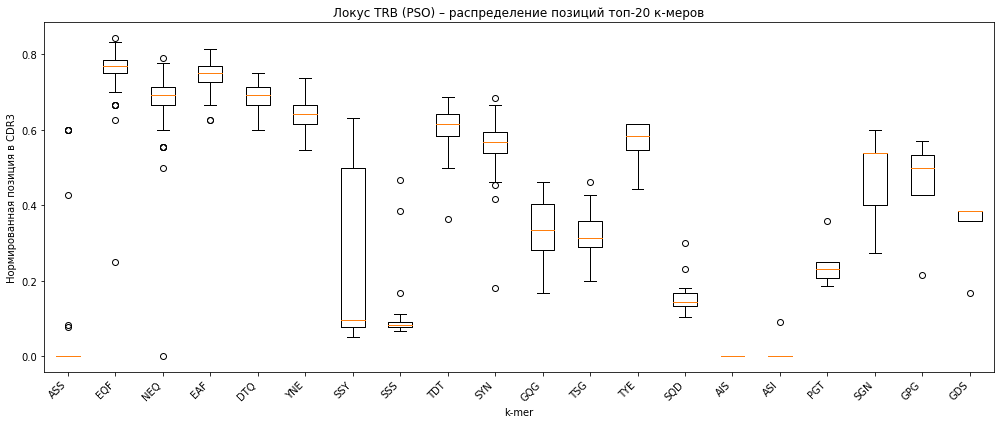

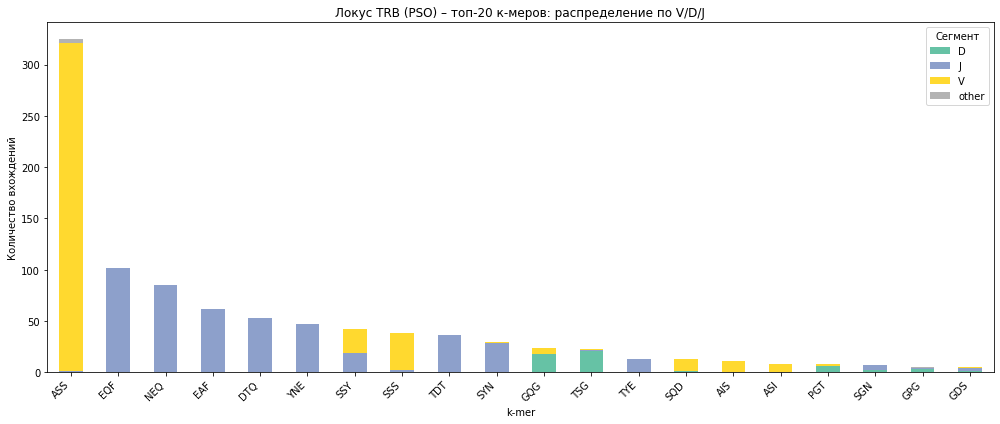


Обработка локуса: IGL (PSO)
  Записей в локусе: 295
  Значимых к-меров в локусе: 39
  Собрано записей в CDR3: 275

  Распределение по генным сегментам для IGL:
gene_segment
V    275
Name: count, dtype: int64
  Топ-20 к-меров для IGL: ['WDS', 'QVW', 'VWD', 'SLS', 'SSL']...


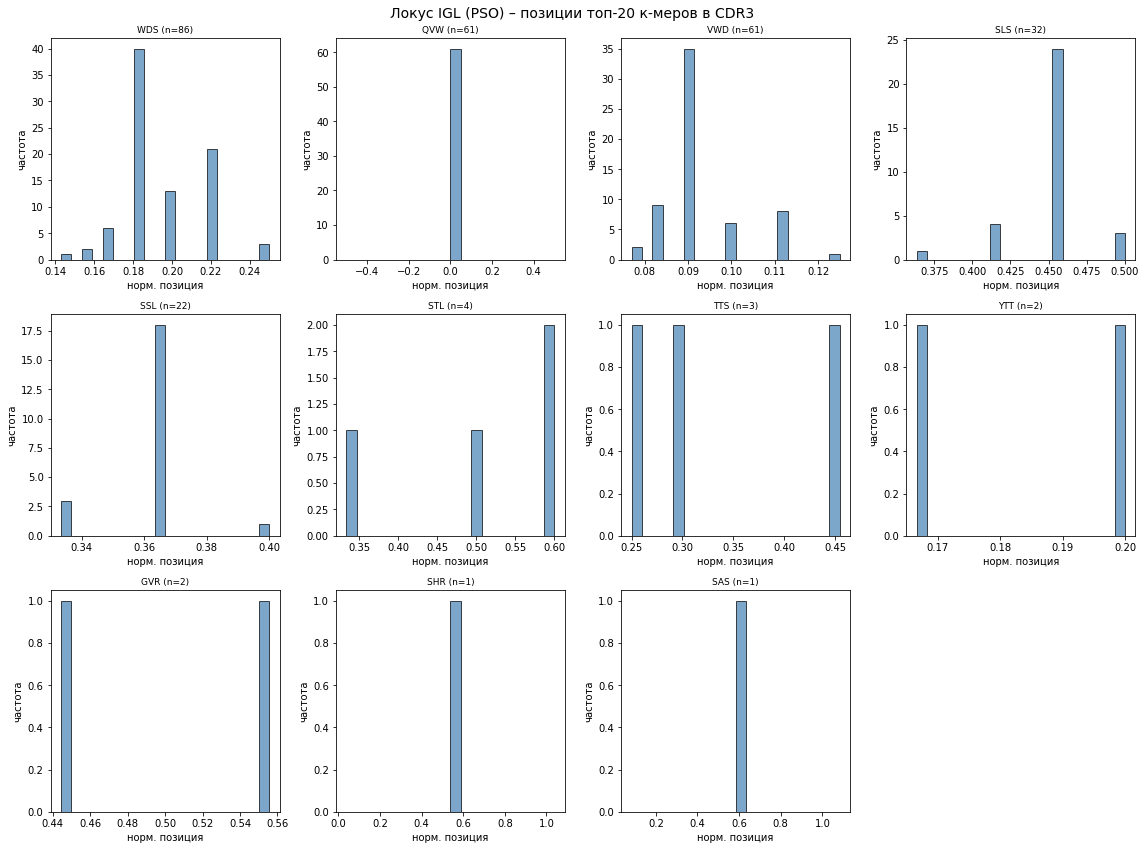

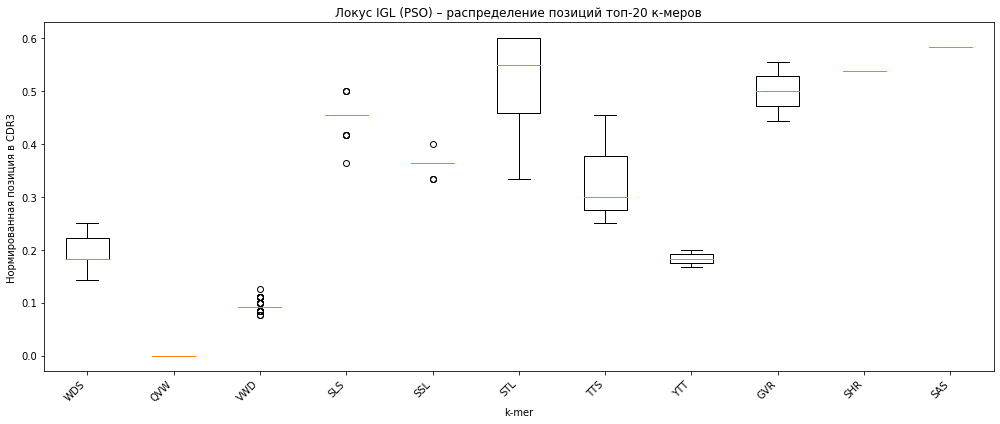

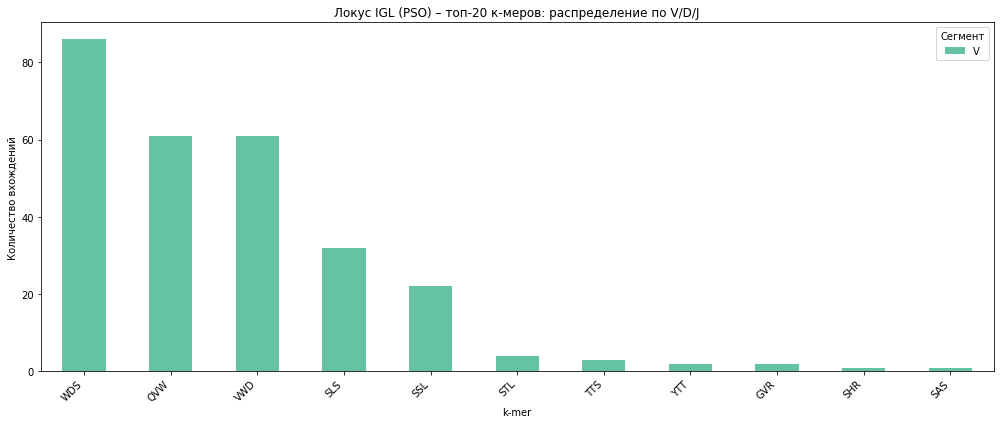


Анализ для PSO завершён. Все результаты в папке cdr3_pso/


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Создаём папку для результатов
os.makedirs("cdr3_pso", exist_ok=True)

# ============================================================
# 1. Загрузка исходных данных (только PSO)
# ============================================================
df_original = pd.read_csv('data_filtered.csv')

df_pso = df_original[
    (df_original['condition'] == 'PSO') &
    (df_original['productive'] == 'T') &
    (df_original['pgen_log'] > -40)
].copy()
print(f"После фильтрации (PSO): {len(df_pso)} записей")
print(f"Локусы: {df_pso['locus'].unique()}")

# ============================================================
# 2. Загрузка значимых к-меров из теста Фишера (CTRL vs PSO)
# ============================================================
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled_pso.csv")
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
df_fisher['significant'] = df_fisher['p_value'] < 0.05
print(f"Всего значимых к-меров (PSO): {df_fisher[df_fisher['significant']].shape[0]}")

# ============================================================
# 3. Функции для перевода координат и определения сегментов
# ============================================================
def nucleotide_to_aa_pos(nuc_pos):
    if pd.isna(nuc_pos) or nuc_pos < 0:
        return np.nan
    return (int(nuc_pos) - 1) // 3 + 1

def get_gene_segment(row, kmer_start_in_cdr3, kmer_len=3):
    required = ['cdr3_start', 'v_sequence_start', 'v_sequence_end', 
                'j_sequence_start', 'j_sequence_end']
    for col in required:
        if col not in row.index or pd.isna(row[col]):
            return 'unknown'
    cdr3_start_aa = nucleotide_to_aa_pos(row['cdr3_start'])
    v_start_aa = nucleotide_to_aa_pos(row['v_sequence_start'])
    v_end_aa = nucleotide_to_aa_pos(row['v_sequence_end'])
    j_start_aa = nucleotide_to_aa_pos(row['j_sequence_start'])
    j_end_aa = nucleotide_to_aa_pos(row['j_sequence_end'])
    if any(pd.isna(x) for x in [cdr3_start_aa, v_start_aa, v_end_aa, j_start_aa, j_end_aa]):
        return 'unknown'
    abs_start = cdr3_start_aa + kmer_start_in_cdr3
    abs_end = abs_start + kmer_len - 1
    if v_start_aa <= abs_start <= v_end_aa or v_start_aa <= abs_end <= v_end_aa:
        return 'V'
    if j_start_aa <= abs_start <= j_end_aa or j_start_aa <= abs_end <= j_end_aa:
        return 'J'
    if 'd_sequence_start' in row and 'd_sequence_end' in row:
        if not pd.isna(row['d_sequence_start']) and not pd.isna(row['d_sequence_end']):
            d_start_aa = nucleotide_to_aa_pos(row['d_sequence_start'])
            d_end_aa = nucleotide_to_aa_pos(row['d_sequence_end'])
            if not pd.isna(d_start_aa) and not pd.isna(d_end_aa):
                if d_start_aa <= abs_start <= d_end_aa or d_start_aa <= abs_end <= d_end_aa:
                    return 'D'
    return 'other'

def get_cdr3_position_info(kmer, cdr3_seq):
    if pd.isna(cdr3_seq) or not isinstance(cdr3_seq, str):
        return None
    pos = cdr3_seq.find(kmer)
    if pos == -1:
        return None
    cdr3_len = len(cdr3_seq)
    norm_pos = pos / cdr3_len if cdr3_len > 0 else np.nan
    return {'cdr3_start_index': pos, 'cdr3_len': cdr3_len, 'norm_position': norm_pos}

# ============================================================
# 4. Анализ по каждому локусу отдельно (только PSO)
# ============================================================
loci = df_pso['locus'].unique()

for locus in loci:
    print(f"\n{'='*60}")
    print(f"Обработка локуса: {locus} (PSO)")
    print(f"{'='*60}")
    
    df_locus = df_pso[df_pso['locus'] == locus].copy()
    print(f"  Записей в локусе: {len(df_locus)}")
    
    sig_kmers_locus = df_fisher[(df_fisher['locus'] == locus) & (df_fisher['significant'])]['kmer'].unique()
    print(f"  Значимых к-меров в локусе: {len(sig_kmers_locus)}")
    if len(sig_kmers_locus) == 0:
        print(f"  Нет значимых к-меров для локуса {locus}, пропускаем.")
        continue
    
    records = []
    kmer_len = 3
    for kmer in sig_kmers_locus:
        # regex=False для буквального поиска
        mask = df_locus['cdr3_aa'].str.contains(kmer, na=False, regex=False)
        if not mask.any():
            continue
        for idx, row in df_locus[mask].iterrows():
            cdr3 = row['cdr3_aa']
            if not isinstance(cdr3, str) or len(cdr3) < kmer_len:
                continue
            start = cdr3.find(kmer)
            if start == -1:
                continue
            info = get_cdr3_position_info(kmer, cdr3)
            if info is None:
                continue
            segment = get_gene_segment(row, info['cdr3_start_index'], kmer_len)
            records.append({
                'kmer': kmer,
                'sample_id': row['sample_id'],
                'cdr3_seq': cdr3,
                'cdr3_len': info['cdr3_len'],
                'start_index': info['cdr3_start_index'],
                'norm_position': info['norm_position'],
                'gene_segment': segment
            })
    
    if len(records) == 0:
        print(f"  Нет вхождений в CDR3 для локуса {locus}")
        continue
    
    df_cdr3_locus = pd.DataFrame(records)
    print(f"  Собрано записей в CDR3: {len(df_cdr3_locus)}")
    print(f"\n  Распределение по генным сегментам для {locus}:")
    print(df_cdr3_locus['gene_segment'].value_counts())
    
    # Сохраняем таблицы
    df_cdr3_locus.to_csv(f"cdr3_pso/{locus}_kmer_cdr3_positions.csv", index=False)
    
    # Сводная статистика
    summary = df_cdr3_locus.groupby('kmer').agg(
        n_hits=('kmer', 'count'),
        mean_norm_pos=('norm_position', 'mean'),
        std_norm_pos=('norm_position', 'std'),
        most_common_segment=('gene_segment', lambda x: x.mode()[0] if len(x) > 0 else 'none')
    ).reset_index()
    summary.to_csv(f"cdr3_pso/{locus}_kmer_cdr3_summary.csv", index=False)
    
    # Топ-20 к-меров по частоте
    top20_kmers = df_cdr3_locus['kmer'].value_counts().head(20).index
    print(f"  Топ-20 к-меров для {locus}: {list(top20_kmers)[:5]}...")
    if len(top20_kmers) == 0:
        continue
    
    # Гистограммы
    n_cols = 4
    n_rows = (len(top20_kmers) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    for i, kmer in enumerate(top20_kmers):
        ax = axes[i]
        sub = df_cdr3_locus[df_cdr3_locus['kmer'] == kmer]['norm_position'].dropna()
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'нет данных', ha='center', va='center')
            ax.set_title(kmer)
            continue
        ax.hist(sub, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(f'{kmer} (n={len(sub)})', fontsize=9)
        ax.set_xlabel('норм. позиция')
        ax.set_ylabel('частота')
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(f'Локус {locus} (PSO) – позиции топ-20 к-меров в CDR3', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"cdr3_pso/{locus}_top20_cdr3_histograms.png", dpi=150)
    plt.show()
    plt.close()
    
    # Boxplot
    plt.figure(figsize=(14, 6))
    data_for_box = []
    valid_labels = []
    for kmer in top20_kmers:
        vals = df_cdr3_locus[df_cdr3_locus['kmer'] == kmer]['norm_position'].dropna().values
        if len(vals) > 0:
            data_for_box.append(vals)
            valid_labels.append(kmer)
    if data_for_box:
        plt.boxplot(data_for_box, labels=valid_labels)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('k-mer')
        plt.ylabel('Нормированная позиция в CDR3')
        plt.title(f'Локус {locus} (PSO) – распределение позиций топ-20 к-меров')
        plt.tight_layout()
        plt.savefig(f"cdr3_pso/{locus}_top20_cdr3_boxplot.png", dpi=150)
        plt.show()
    plt.close()
    
    # Stacked bar chart по сегментам
    segment_counts = df_cdr3_locus[df_cdr3_locus['kmer'].isin(top20_kmers)].groupby(['kmer', 'gene_segment']).size().unstack(fill_value=0)
    segment_counts = segment_counts.reindex(top20_kmers, fill_value=0)
    if not segment_counts.empty:
        segment_counts.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set2')
        plt.xlabel('k-mer')
        plt.ylabel('Количество вхождений')
        plt.title(f'Локус {locus} (PSO) – топ-20 к-меров: распределение по V/D/J')
        plt.legend(title='Сегмент')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f"cdr3_pso/{locus}_top20_cdr3_segments.png", dpi=150)
        plt.show()
    plt.close()

print("\n" + "="*60)
print("Анализ для PSO завершён. Все результаты в папке cdr3_pso/")

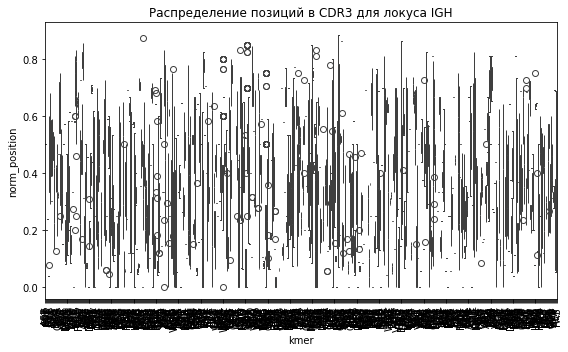

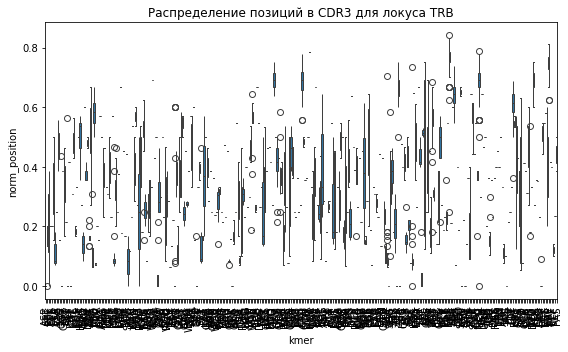

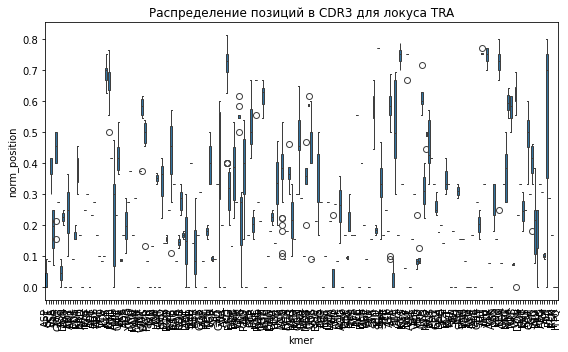

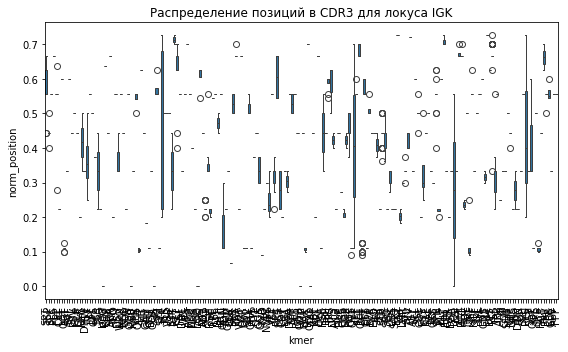

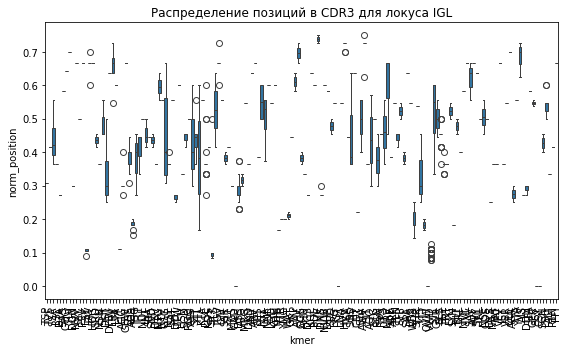

In [14]:
for locus in df_cdr3_pso['locus'].unique():
    sub = df_cdr3_pso[df_cdr3_pso['locus'] == locus]
    if sub.empty:
        continue
    plt.figure(figsize=(8,5))
    sns.boxplot(data=sub, x='kmer', y='norm_position')
    plt.xticks(rotation=90)
    plt.title(f'Распределение позиций в CDR3 для локуса {locus}')
    plt.tight_layout()
   # plt.savefig(f"cdr3/cdr3_positions_{locus}.png", dpi=150)
    plt.show()
    plt.close()

код, который:

    Загружает объединённую таблицу TF-IDF + Fisher (например, для AD или PSO).

    Фильтрует значимые к-меры (p < 0.05) и сортирует по diff_tfidf (по убыванию) и/или по p_value (по возрастанию).

    Выбирает топ-50 уникальных k-меров.

    Для каждого к-мера находит соответствующие последовательности CDR3 (из исходных данных) и сохраняет в CSV/FASTA для ручного поиска в VDJdb и IEDB.

In [15]:
import pandas as pd
import numpy as np
import os

# ============================================================
# Настройки: выберите сравнение и папки
# ============================================================
comparison = "AD"   # или "PSO" - для CTRL vs PSO
if comparison == "AD":
    fisher_file = "fishertest/fisher_results_all_loci_pooled.csv"
    tfidf_dir = "tf_idf"   # папка с объединёнными tfidf_fisher_merged_*.csv
    output_dir = "top_sequences_AD"
elif comparison == "PSO":
    fisher_file = "fishertest_pso/fisher_results_all_loci_pooled_pso.csv"
    tfidf_dir = "tf_idf"   # если есть для PSO, иначе придётся пересчитать (но мы можем взять fisher только)
    output_dir = "top_sequences_PSO"
else:
    raise ValueError("Выберите 'AD' или 'PSO'")

os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 1. Загрузка данных Фишера (значимые к-меры)
# ============================================================
df_fisher = pd.read_csv(fisher_file)
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]
df_fisher['significant'] = df_fisher['p_value'] < 0.05
df_fisher_sig = df_fisher[df_fisher['significant']].copy()
print(f"Всего значимых к-меров: {len(df_fisher_sig)}")

# ============================================================
# 2. Загрузка объединённых TF-IDF таблиц (для diff_tfidf)
#    Если файлов нет, можно использовать только Фишера
# ============================================================
# Пытаемся загрузить объединённые данные для всех локусов
all_tfidf = []
for locus in df_fisher_sig['locus'].unique():
    tfidf_file = f"{tfidf_dir}/tfidf_fisher_merged_{locus}.csv"
    if os.path.exists(tfidf_file):
        df_tmp = pd.read_csv(tfidf_file)
        all_tfidf.append(df_tmp)
    else:
        print(f"Предупреждение: файл {tfidf_file} не найден. Используем только Fisher.")
if all_tfidf:
    df_merged = pd.concat(all_tfidf, ignore_index=True)
    # Убедимся, что колонки есть
    if 'diff_tfidf' not in df_merged.columns:
        print("Нет diff_tfidf, используем только p_value")
        df_merged = None
else:
    df_merged = None

# Если объединённые данные есть, берём их; иначе используем df_fisher_sig
if df_merged is not None:
    # Оставляем только значимые
    df_merged = df_merged[df_merged['significant'] == True]
    # Сортировка: сначала по diff_tfidf (по убыванию), затем по p_value (возрастание)
    df_merged = df_merged.sort_values(['diff_tfidf', 'p_value'], ascending=[False, True])
    top_kmers = df_merged.head(50)['kmer'].unique()
    print(f"Топ-50 по diff_tfidf (p<0.05) выбрано {len(top_kmers)} к-меров")
else:
    # Сортируем по p_value
    df_fisher_sig = df_fisher_sig.sort_values('p_value')
    top_kmers = df_fisher_sig.head(50)['kmer'].unique()
    print(f"Топ-50 по p_value (p<0.05) выбрано {len(top_kmers)} к-меров")

# ============================================================
# 3. Загрузка исходных данных для получения CDR3 и другой информации
# ============================================================
df_original = pd.read_csv('data_filtered.csv')

# Фильтруем нужные группы (в зависимости от сравнения)
if comparison == "AD":
    df_group = df_original[df_original['condition'] == 'AD'].copy()
else:
    df_group = df_original[df_original['condition'] == 'PSO'].copy()

# Оставляем только продуктивные и с хорошим pgen_log
df_group = df_group[(df_group['productive'] == 'T') & (df_group['pgen_log'] > -40)]

# ============================================================
# 4. Сбор информации о топ-к-мерах: какие CDR3 их содержат
# ============================================================
records = []
for kmer in top_kmers:
    # Ищем CDR3, содержащие этот k-мер (используем regex=False)
    mask = df_group['cdr3_aa'].str.contains(kmer, na=False, regex=False)
    if not mask.any():
        continue
    for idx, row in df_group[mask].iterrows():
        cdr3 = row['cdr3_aa']
        locus = row['locus']
        sample_id = row['sample_id']
        v_call = row.get('v_call', '')
        records.append({
            'kmer': kmer,
            'cdr3_aa': cdr3,
            'locus': locus,
            'sample_id': sample_id,
            'v_call': v_call,
            'condition': row['condition']
        })

df_top = pd.DataFrame(records)
print(f"Собрано записей: {len(df_top)}")

# Сохраняем в CSV
df_top.to_csv(f"{output_dir}/top50_kmers_cdr3_sequences.csv", index=False)

# ============================================================
# 5. Экспорт уникальных CDR3 для поиска в VDJdb/IEDB (FASTA)
# ============================================================
unique_cdr3 = df_top['cdr3_aa'].drop_duplicates().tolist()
with open(f"{output_dir}/unique_cdr3_for_search.fasta", "w") as f:
    for seq in unique_cdr3:
        f.write(f">{seq}\n{seq}\n")

print(f"Уникальных CDR3: {len(unique_cdr3)}. Сохранено в FASTA.")

# Дополнительно: создать файл с k-мерами и связанными V-генами для анализа предпочтений V-генов
v_kmer_counts = df_top.groupby(['v_call', 'kmer']).size().reset_index(name='count')
v_kmer_counts.to_csv(f"{output_dir}/v_call_kmer_associations.csv", index=False)

print(f"Готово. Все файлы в папке {output_dir}")

Всего значимых к-меров: 1238
Топ-50 по diff_tfidf (p<0.05) выбрано 50 к-меров
Собрано записей: 183
Уникальных CDR3: 164. Сохранено в FASTA.
Готово. Все файлы в папке top_sequences_AD


Локусы: ['IGH' 'IGK' 'IGL' 'TRA' 'TRB']

=== Обработка локуса IGH (CTRL vs PSO) ===
Сохранено 8547 к-меров в tfidf_pso/tfidf_fisher_merged_IGH.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (PSO):
kmer  diff_tfidf  odds_ratio  p_value
 GVX    0.005019         0.0      1.0
 NDN    0.005019         0.0      1.0
 PXY    0.005019         0.0      1.0
 XYK    0.005019         0.0      1.0
 YNC    0.005019         0.0      1.0


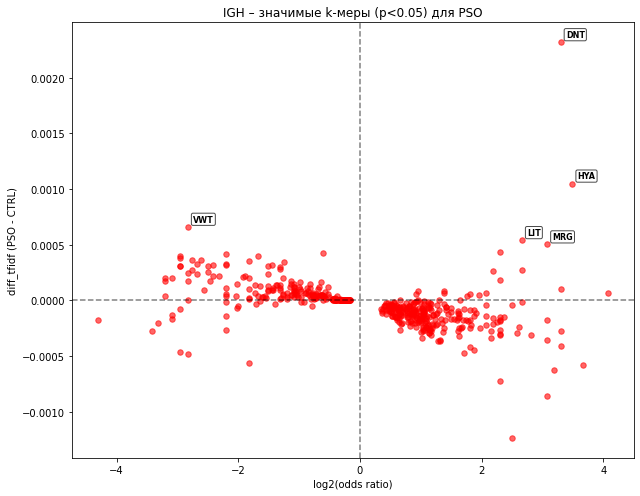


=== Обработка локуса IGK (CTRL vs PSO) ===
Сохранено 3892 к-меров в tfidf_pso/tfidf_fisher_merged_IGK.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (PSO):
kmer  diff_tfidf  odds_ratio  p_value
 NWA    0.066497         0.0 0.235440
 HHS    0.056522         0.0 0.485225
 HSV    0.056522         0.0 0.485225
 LTG    0.056522         0.0 0.485225
 PKR    0.056522         0.0 0.485225


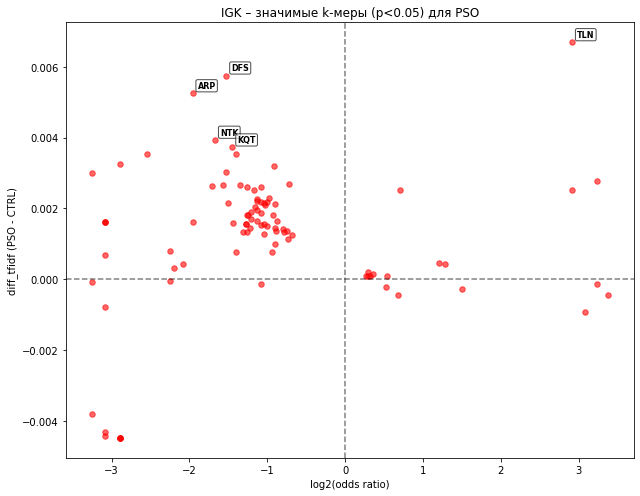


=== Обработка локуса IGL (CTRL vs PSO) ===
Сохранено 3011 к-меров в tfidf_pso/tfidf_fisher_merged_IGL.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (PSO):
kmer  diff_tfidf  odds_ratio  p_value
 GKN    0.114435         0.0      1.0
 NLW    0.100812         0.0      1.0
 DDK    0.092046         0.0      1.0
 DKM    0.092046         0.0      1.0
 KMR    0.092046         0.0      1.0


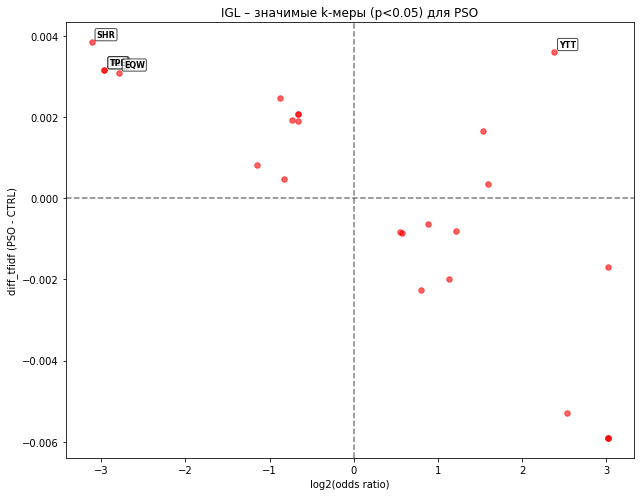


=== Обработка локуса TRA (CTRL vs PSO) ===
Сохранено 3771 к-меров в tfidf_pso/tfidf_fisher_merged_TRA.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (PSO):
kmer  diff_tfidf  odds_ratio  p_value
 EPP    0.106056         0.0      1.0
 VEP    0.106056         0.0      1.0
 MGF    0.092799         0.0      1.0
 REM    0.092799         0.0      1.0
 DGG    0.089087         0.0      1.0


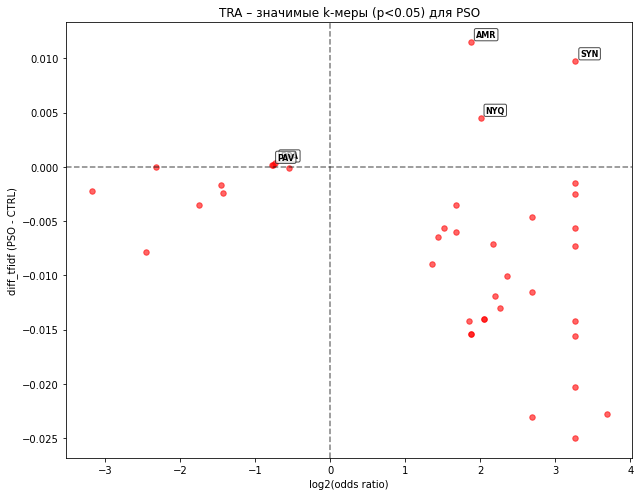


=== Обработка локуса TRB (CTRL vs PSO) ===
Сохранено 6490 к-меров в tfidf_pso/tfidf_fisher_merged_TRB.csv

Топ-5 к-меров с наибольшим приростом TF-IDF у больных (PSO):
kmer  diff_tfidf  odds_ratio  p_value
 ERN    0.034173         0.0      1.0
 GFI    0.034173         0.0      1.0
 IVW    0.034173         0.0      1.0
 KSX    0.034173         0.0      1.0
 NKS    0.034173         0.0      1.0


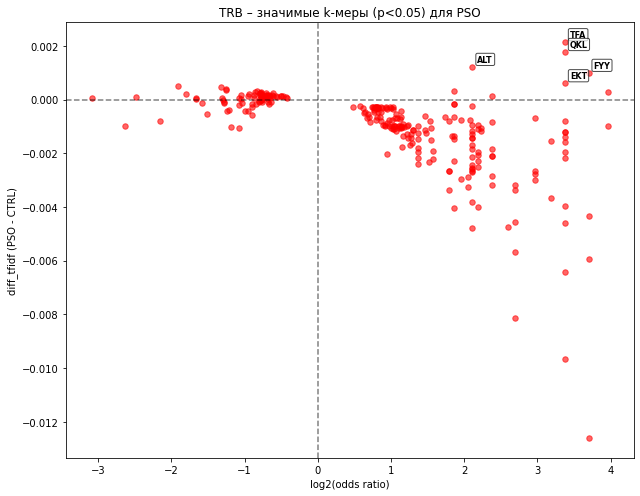


Анализ TF-IDF для PSO завершён. Результаты в папке tfidf_pso/


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Создаём папку для результатов TF-IDF PSO
os.makedirs("tfidf_pso", exist_ok=True)

# ============================================================
# 1. Загрузка данных (только CTRL и PSO)
# ============================================================
df_kmers = pd.read_csv("df_kmers_PSO.csv")                      # таблица с usage для CTRL и PSO
df_fisher = pd.read_csv("fishertest/fisher_results_all_loci_pooled_pso.csv")  # результаты Фишера для PSO

# Исключаем k-меры со звёздочкой
df_kmers = df_kmers[~df_kmers['kmer'].str.contains('\*', na=False)]
df_fisher = df_fisher[~df_fisher['kmer'].str.contains('\*', na=False)]

loci = df_kmers['locus'].unique()
print("Локусы:", loci)

# ============================================================
# 2. Функция для вычисления TF-IDF (на основе usage) для CTRL vs PSO
# ============================================================
def compute_tfidf_usage_based_pso(df_kmers, locus):
    sub = df_kmers[df_kmers['locus'] == locus].copy()
    all_samples = sub['sample_id'].unique()
    N_total = len(all_samples)
    
    kmer_stats = {}
    for kmer, group in sub.groupby('kmer'):
        samples_with = group['sample_id'].unique()
        n_samples_with = len(samples_with)
        mean_usage_ctrl = group[group['condition'] == 'CTRL']['usage'].mean() if (group['condition'] == 'CTRL').any() else 0
        mean_usage_pso = group[group['condition'] == 'PSO']['usage'].mean() if (group['condition'] == 'PSO').any() else 0
        kmer_stats[kmer] = {
            'n_samples_with': n_samples_with,
            'mean_usage_ctrl': mean_usage_ctrl,
            'mean_usage_pso': mean_usage_pso
        }
    
    results = []
    for kmer, stats in kmer_stats.items():
        n_with = stats['n_samples_with']
        idf = np.log(N_total / (n_with + 1e-9))
        tfidf_ctrl = stats['mean_usage_ctrl'] * idf
        tfidf_pso = stats['mean_usage_pso'] * idf
        results.append({
            'kmer': kmer,
            'tf_ctrl': stats['mean_usage_ctrl'],
            'tf_pso': stats['mean_usage_pso'],
            'idf': idf,
            'tfidf_ctrl': tfidf_ctrl,
            'tfidf_pso': tfidf_pso,
            'diff_tfidf': tfidf_pso - tfidf_ctrl,
            'n_samples_with': n_with
        })
    return pd.DataFrame(results)

# ============================================================
# 3. Основной цикл по локусам для PSO
# ============================================================
for locus in loci:
    print(f"\n=== Обработка локуса {locus} (CTRL vs PSO) ===")
    
    df_tfidf = compute_tfidf_usage_based_pso(df_kmers, locus)
    df_fish_locus = df_fisher[df_fisher['locus'] == locus][['kmer', 'odds_ratio', 'p_value']].copy()
    df_merged = pd.merge(df_tfidf, df_fish_locus, on='kmer', how='inner')
    df_merged['log2OR'] = np.log2(df_merged['odds_ratio'].replace(0, np.nan))
    df_merged['significant'] = df_merged['p_value'] < 0.05
    
    # Сохраняем полную таблицу
    output_file = f"tfidf_pso/tfidf_fisher_merged_{locus}.csv"
    df_merged.to_csv(output_file, index=False)
    print(f"Сохранено {len(df_merged)} к-меров в {output_file}")
    
    # Топ-5 по diff_tfidf (положительные – характерны для PSO)
    top_diff = df_merged.nlargest(5, 'diff_tfidf')
    print("\nТоп-5 к-меров с наибольшим приростом TF-IDF у больных (PSO):")
    print(top_diff[['kmer', 'diff_tfidf', 'odds_ratio', 'p_value']].to_string(index=False))
    
    # График diff_tfidf vs log2(odds_ratio) для значимых
    sig = df_merged[df_merged['significant']].dropna(subset=['log2OR', 'diff_tfidf'])
    if not sig.empty:
        plt.figure(figsize=(9, 7))
        plt.scatter(sig['log2OR'], sig['diff_tfidf'], alpha=0.6, s=30, color='red')
        top5_abs = sig.nlargest(5, 'diff_tfidf').copy()
        for _, row in top5_abs.iterrows():
            plt.annotate(row['kmer'],
                         xy=(row['log2OR'], row['diff_tfidf']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=8, weight='bold',
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
        plt.axhline(0, color='black', linestyle='--', alpha=0.5)
        plt.axvline(0, color='black', linestyle='--', alpha=0.5)
        plt.xlabel('log2(odds ratio)')
        plt.ylabel('diff_tfidf (PSO - CTRL)')
        plt.title(f'{locus} – значимые k-меры (p<0.05) для PSO')
        plt.tight_layout()
        plt.savefig(f"tfidf_pso/diff_tfidf_vs_log2OR_{locus}.png", dpi=150)
        plt.show()
        plt.close()
    else:
        print("Нет значимых к-меров для построения графика.")

print("\nАнализ TF-IDF для PSO завершён. Результаты в папке tfidf_pso/")

In [2]:
import pandas as pd
import numpy as np
import os

# ============================================================
# 1. Загрузка данных
# ============================================================
df_ad = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
df_pso = pd.read_csv("fishertest/fisher_results_all_loci_pooled_pso.csv")
df_original = pd.read_csv('data_filtered.csv')

# ============================================================
# 2. Отбор значимых k-меров (p < 0.05)
# ============================================================
df_ad_sig = df_ad[df_ad['p_value'] < 0.05].copy()
df_pso_sig = df_pso[df_pso['p_value'] < 0.05].copy()

df_ad_sig['association'] = np.where(df_ad_sig['odds_ratio'] > 1, 'AD_associated', 'CTRL_associated')
df_pso_sig['association'] = np.where(df_pso_sig['odds_ratio'] > 1, 'PSO_associated', 'CTRL_associated')

print(f"AD: значимых k-меров - {len(df_ad_sig)}, из них ассоциированных с AD - {sum(df_ad_sig['association'] == 'AD_associated')}")
print(f"PSO: значимых k-меров - {len(df_pso_sig)}, из них ассоциированных с PSO - {sum(df_pso_sig['association'] == 'PSO_associated')}")

# ============================================================
# 3. Загрузка данных о позициях в CDR3 (если есть)
# ============================================================
try:
    df_cdr3_ad = pd.read_csv("cdr3/kmer_cdr3_positions_with_segments.csv")
    has_cdr3_ad = True
except:
    df_cdr3_ad = pd.DataFrame()
    has_cdr3_ad = False

try:
    df_cdr3_pso = pd.read_csv("cdr3_pso/kmer_cdr3_positions_with_segments.csv")
    has_cdr3_pso = True
except:
    df_cdr3_pso = pd.DataFrame()
    has_cdr3_pso = False

# ============================================================
# 4. Функция для создания сводной таблицы
# ============================================================
def create_summary_table(df_sig, disease_name, df_cdr3, df_original):
    """
    Создаёт сводную таблицу для одного заболевания.
    """
    summary = df_sig[['locus', 'kmer', 'odds_ratio', 'p_value', 'association']].copy()
    
    # Добавляем информацию о V-гене (из исходных данных)
    v_call_list = []
    for kmer in summary['kmer']:
        mask = df_original['sequence_aa'].str.contains(kmer, na=False, regex=False)
        if mask.any():
            v_calls = df_original.loc[mask, 'v_call'].value_counts()
            v_call_list.append(v_calls.index[0] if not v_calls.empty else 'unknown')
        else:
            v_call_list.append('unknown')
    summary['v_call'] = v_call_list
    
    # Добавляем информацию о происхождении (из CDR3 данных)
    if not df_cdr3.empty:
        origin_list = []
        for kmer in summary['kmer']:
            sub = df_cdr3[df_cdr3['kmer'] == kmer]
            if not sub.empty:
                origin = sub['gene_segment'].value_counts().index[0]
            else:
                origin = 'no_cdr3_hit'
            origin_list.append(origin)
        summary['origin'] = origin_list
    else:
        summary['origin'] = 'unknown'
    
    return summary

# Создаём итоговые таблицы
summary_ad = create_summary_table(df_ad_sig, 'AD', df_cdr3_ad, df_original)
summary_pso = create_summary_table(df_pso_sig, 'PSO', df_cdr3_pso, df_original)

# Сохраняем
summary_ad.to_csv("summary_AD_kmers.csv", index=False)
summary_pso.to_csv("summary_PSO_kmers.csv", index=False)

# ============================================================
# 5. Сводка по локусам и происхождению
# ============================================================
def locus_origin_summary(summary, disease_name):
    result = []
    for locus in summary['locus'].unique():
        sub = summary[summary['locus'] == locus]
        total = len(sub)
        disease_associated = sum(sub['association'] == f'{disease_name}_associated')
        ctrl_associated = total - disease_associated
        origin_counts = sub['origin'].value_counts().to_dict()
        result.append({
            'locus': locus,
            'total_kmers': total,
            f'{disease_name}_associated': disease_associated,
            'CTRL_associated': ctrl_associated,
            'origin_V': origin_counts.get('V', 0),
            'origin_J': origin_counts.get('J', 0),
            'origin_VD': origin_counts.get('VD', 0),
            'origin_DJ': origin_counts.get('DJ', 0),
            'origin_VJ': origin_counts.get('VJ', 0),
            'origin_other': origin_counts.get('other', 0),
            'origin_unknown': origin_counts.get('unknown', 0) + origin_counts.get('no_cdr3_hit', 0)
        })
    return pd.DataFrame(result)

summary_by_locus_ad = locus_origin_summary(summary_ad, 'AD')
summary_by_locus_pso = locus_origin_summary(summary_pso, 'PSO')

summary_by_locus_ad.to_csv("summary_AD_by_locus.csv", index=False)
summary_by_locus_pso.to_csv("summary_PSO_by_locus.csv", index=False)

print("\n=== AD: Сводка по локусам ===")
print(summary_by_locus_ad.to_string(index=False))

print("\n=== PSO: Сводка по локусам ===")
print(summary_by_locus_pso.to_string(index=False))

# ============================================================
# 6. Сравнение AD и PSO
# ============================================================
ad_kmers = set(summary_ad['kmer'])
pso_kmers = set(summary_pso['kmer'])

common = ad_kmers & pso_kmers
only_ad = ad_kmers - pso_kmers
only_pso = pso_kmers - ad_kmers

comparison = pd.DataFrame({
    'category': ['Общие', 'Только AD', 'Только PSO'],
    'count': [len(common), len(only_ad), len(only_pso)]
})
comparison.to_csv("comparison_AD_vs_PSO.csv", index=False)

print("\n=== Сравнение AD и PSO ===")
print(comparison.to_string(index=False))

# Сохраняем списки к-меров
pd.Series(list(common)).to_csv("common_kmers_AD_PSO.csv", index=False)
pd.Series(list(only_ad)).to_csv("only_AD_kmers.csv", index=False)
pd.Series(list(only_pso)).to_csv("only_PSO_kmers.csv", index=False)

print("\nВсе результаты сохранены в CSV файлы.")

AD: значимых k-меров - 1368, из них ассоциированных с AD - 830
PSO: значимых k-меров - 1175, из них ассоциированных с PSO - 670

=== AD: Сводка по локусам ===
locus  total_kmers  AD_associated  CTRL_associated  origin_V  origin_J  origin_VD  origin_DJ  origin_VJ  origin_other  origin_unknown
  IGH          663            375              288       198       118          0          0          0            69             200
  IGK           79             22               57        31         9          0          0          0             7              24
  IGL           41              4               37        22         8          0          0          0             1               1
  TRA          158            122               36        35        26          0          0          0            21              57
  TRB          427            307              120       111        60          0          0          0            36             174

=== PSO: Сводка по локусам ===
locus

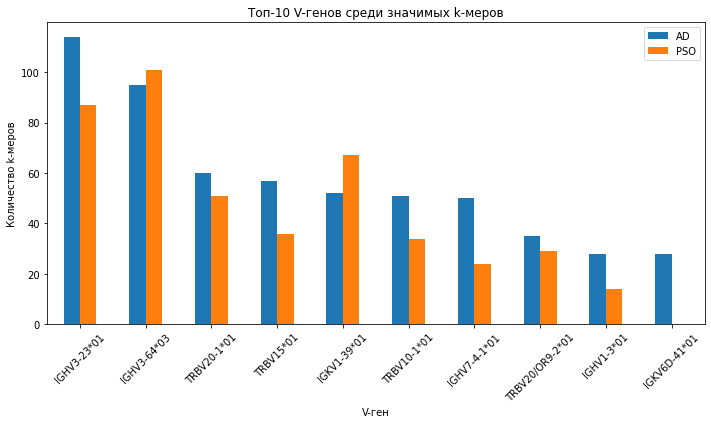

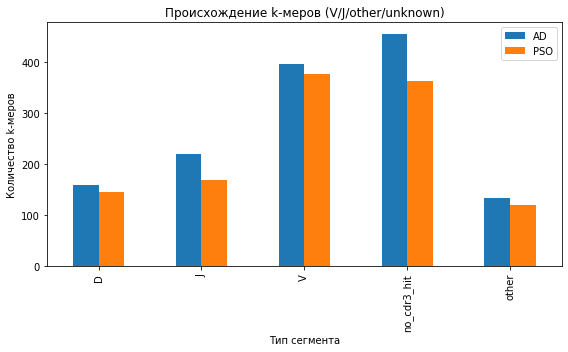

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем сводные таблицы
summary_ad = pd.read_csv("summary_AD_kmers.csv")
summary_pso = pd.read_csv("summary_PSO_kmers.csv")

# Функция для подсчета частот V-генов и J-генов
def analyze_vj_genes(summary, disease_name):
    # V-гены
    v_counts = summary['v_call'].value_counts().head(20)
    # J-гены (если есть колонка j_call, но у нас нет, можно извлечь из v_call? нет)
    # Можно использовать origin для J, но там не указан конкретный J-ген.
    # Поэтому ограничимся V.
    return v_counts

v_ad = analyze_vj_genes(summary_ad, 'AD')
v_pso = analyze_vj_genes(summary_pso, 'PSO')

# Объединим для сравнения
v_combined = pd.DataFrame({'AD': v_ad, 'PSO': v_pso}).fillna(0)
v_combined = v_combined.loc[v_combined.sum(axis=1) > 0].sort_values(by='AD', ascending=False)

# Визуализация топ-10 V-генов
top_v = v_combined.head(10)
top_v.plot(kind='bar', figsize=(10,6))
plt.title('Топ-10 V-генов среди значимых k-меров')
plt.xlabel('V-ген')
plt.ylabel('Количество k-меров')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_v_genes_AD_PSO.png', dpi=150)
plt.show()

# Аналогично для происхождения (V, J, other, unknown)
origin_ad = summary_ad['origin'].value_counts()
origin_pso = summary_pso['origin'].value_counts()
origin_combined = pd.DataFrame({'AD': origin_ad, 'PSO': origin_pso}).fillna(0)
origin_combined.plot(kind='bar', figsize=(8,5))
plt.title('Происхождение k-меров (V/J/other/unknown)')
plt.xlabel('Тип сегмента')
plt.ylabel('Количество k-меров')
plt.tight_layout()
plt.savefig('origin_comparison_AD_PSO.png', dpi=150)
plt.show()

In [4]:
# Объединение по kmer
merged = pd.merge(summary_ad[['kmer', 'association', 'odds_ratio']], 
                  summary_pso[['kmer', 'association', 'odds_ratio']], 
                  on='kmer', suffixes=('_AD', '_PSO'), how='inner')

# Общие k-меры
common_kmers = merged
# Смотрим, сколько имеют одинаковое направление
common_kmers['same_direction'] = (common_kmers['association_AD'] == common_kmers['association_PSO'])
print(f"Общие k-меры: {len(common_kmers)}")
print(f"Одинаковое направление: {common_kmers['same_direction'].sum()}")
print(f"Разное направление: {len(common_kmers) - common_kmers['same_direction'].sum()}")

# Для разных направлений можно вывести примеры
diff = common_kmers[~common_kmers['same_direction']]
print(diff[['kmer', 'association_AD', 'association_PSO', 'odds_ratio_AD', 'odds_ratio_PSO']].head())

# Сохраним общие k-меры с направлениями
common_kmers.to_csv('common_kmers_with_directions.csv', index=False)

Общие k-меры: 723
Одинаковое направление: 249
Разное направление: 474
  kmer association_AD association_PSO  odds_ratio_AD  odds_ratio_PSO
0  ASP  AD_associated  PSO_associated       3.489324        2.188227
1  ASP  AD_associated  PSO_associated       2.167019        2.188227
2  SPT  AD_associated  PSO_associated       3.422303        2.223982
3  SPT  AD_associated  PSO_associated       3.422303        8.096590
4  PTS  AD_associated  PSO_associated       3.313974        2.172413


Общих k-меров: 592
Размер df_common: 723

Распределение по направлениям:
direction
both_disease    392
both_healthy    249
opposite         82
Name: count, dtype: int64


/home/vorlova/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/vorlova/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


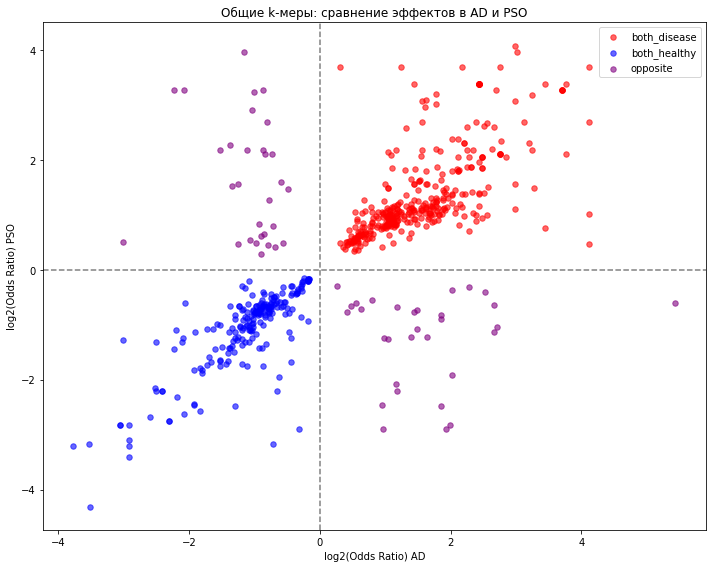


Топ-20 разнонаправленных k-меров:
kmer  log2OR_AD  log2OR_PSO  association_AD association_PSO
 AMY        inf   -1.232978   AD_associated CTRL_associated
 SQD   1.340807        -inf   AD_associated CTRL_associated
 QYF        inf   -0.474624   AD_associated CTRL_associated
 VKA  -0.821208         inf CTRL_associated  PSO_associated
 HTF  -1.606993         inf CTRL_associated  PSO_associated
 GTA        inf   -0.582083   AD_associated CTRL_associated
 SLK  -2.327682         inf CTRL_associated  PSO_associated
 AGR       -inf    2.374989 CTRL_associated  PSO_associated
 SND       -inf    2.816513 CTRL_associated  PSO_associated
 FWY   2.116647        -inf   AD_associated CTRL_associated
 NTP       -inf    1.012801 CTRL_associated  PSO_associated
 VFE        inf   -0.758507   AD_associated CTRL_associated
 QHA        inf   -2.206014   AD_associated CTRL_associated
 NFG  -2.585742         inf CTRL_associated  PSO_associated
 KVR        inf        -inf   AD_associated CTRL_associated
 IQR 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# 1. Загрузка итоговых таблиц
# ============================================================
df_ad = pd.read_csv("summary_AD_kmers.csv")
df_pso = pd.read_csv("summary_PSO_kmers.csv")

# Оставляем нужные колонки
df_ad_sub = df_ad[['kmer', 'odds_ratio', 'association']].rename(
    columns={'odds_ratio': 'odds_ratio_AD', 'association': 'association_AD'}
)
df_pso_sub = df_pso[['kmer', 'odds_ratio', 'association']].rename(
    columns={'odds_ratio': 'odds_ratio_PSO', 'association': 'association_PSO'}
)

# ============================================================
# 2. Находим общие k-меры (пересечение)
# ============================================================
common_kmers = set(df_ad_sub['kmer']) & set(df_pso_sub['kmer'])
print(f"Общих k-меров: {len(common_kmers)}")

# Объединяем
df_common = pd.merge(df_ad_sub, df_pso_sub, on='kmer', how='inner')
# Убедимся, что порядок такой же, как в common_kmers
df_common = df_common[df_common['kmer'].isin(common_kmers)]
print(f"Размер df_common: {len(df_common)}")

# Сохраняем для дальнейшего использования
df_common.to_csv("common_kmers_details.csv", index=False)

# ============================================================
# 3. Добавляем категории направлений
# ============================================================
df_common['log2OR_AD'] = np.log2(df_common['odds_ratio_AD'])
df_common['log2OR_PSO'] = np.log2(df_common['odds_ratio_PSO'])

def get_direction(row):
    if row['association_AD'] == 'AD_associated' and row['association_PSO'] == 'PSO_associated':
        return 'both_disease'
    elif row['association_AD'] == 'CTRL_associated' and row['association_PSO'] == 'CTRL_associated':
        return 'both_healthy'
    else:
        return 'opposite'

df_common['direction'] = df_common.apply(get_direction, axis=1)
print("\nРаспределение по направлениям:")
print(df_common['direction'].value_counts())

# ============================================================
# 4. Scatter plot
# ============================================================
plt.figure(figsize=(10, 8))
colors = {'both_disease': 'red', 'both_healthy': 'blue', 'opposite': 'purple'}
for direction, group in df_common.groupby('direction'):
    plt.scatter(group['log2OR_AD'], group['log2OR_PSO'],
                label=direction, alpha=0.6, s=30, color=colors.get(direction, 'gray'))
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('log2(Odds Ratio) AD')
plt.ylabel('log2(Odds Ratio) PSO')
plt.title('Общие k-меры: сравнение эффектов в AD и PSO')
plt.legend()
plt.tight_layout()
plt.savefig("common_kmers_scatter.png", dpi=150)
plt.show()

# ============================================================
# 5. Топ-20 разнонаправленных с сильным эффектом
# ============================================================
df_opposite = df_common[df_common['direction'] == 'opposite'].copy()
if not df_opposite.empty:
    df_opposite['abs_log2OR'] = (df_opposite['log2OR_AD'].abs() + df_opposite['log2OR_PSO'].abs()) / 2
    top20_opposite = df_opposite.nlargest(20, 'abs_log2OR')[['kmer', 'log2OR_AD', 'log2OR_PSO', 'association_AD', 'association_PSO']]
    print("\nТоп-20 разнонаправленных k-меров:")
    print(top20_opposite.to_string(index=False))
    top20_opposite.to_csv("top20_opposite_kmers.csv", index=False)
else:
    print("Нет разнонаправленных k-меров.")

print("\nАнализ завершен. Сохранены: common_kmers_details.csv, common_kmers_scatter.png, top20_opposite_kmers.csv (если есть).")

In [19]:
import pandas as pd

# Загружаем данные (предполагается, что файл summary_AD_kmers.csv уже есть)
df_ad_sig = pd.read_csv("summary_AD_kmers.csv")

# Убедимся, что колонка 'origin' существует (если нет, замените на правильное название)
if 'origin' not in df_ad_sig.columns:
    print("Колонка 'origin' не найдена. Используйте правильное название.")
    exit()

# Подсчитываем количество значимых k-меров по локусам
locus_counts = df_ad_sig['locus'].value_counts()
loci_ge50 = locus_counts[locus_counts >= 50].index.tolist()
print(f"Локусы с >=50 значимыми k-мерами: {loci_ge50}")

# Фильтруем данные
df_filtered = df_ad_sig[df_ad_sig['locus'].isin(loci_ge50)]

# Группируем по locus и origin, считаем количество
origin_counts = df_filtered.groupby(['locus', 'origin']).size().unstack(fill_value=0)

# Добавляем столбец total
origin_counts['total'] = origin_counts.sum(axis=1)

# Упорядочиваем столбцы: V, J, VD, DJ, VJ, other, unknown, total
desired_order = ['V', 'J', 'VD', 'DJ', 'VJ', 'other', 'unknown', 'total']
existing_cols = [col for col in desired_order if col in origin_counts.columns]
origin_counts = origin_counts[existing_cols]

# Выводим в Markdown
print("\nTable 3. Genomic origin distribution of significant k‑mers (AD vs CTRL). Only loci with at least 50 significant k‑mers are shown.")
print(origin_counts.to_markdown())

# Сохраняем в CSV (опционально)
origin_counts.to_csv("table3_origin_distribution.csv")

Локусы с >=50 значимыми k-мерами: ['IGH', 'TRB', 'TRA', 'IGK']

Table 3. Genomic origin distribution of significant k‑mers (AD vs CTRL). Only loci with at least 50 significant k‑mers are shown.
| locus   |   V |   J |   other |   total |
|:--------|----:|----:|--------:|--------:|
| IGH     | 198 | 118 |      69 |     663 |
| IGK     |  31 |   9 |       7 |      79 |
| TRA     |  35 |  26 |      21 |     158 |
| TRB     | 111 |  60 |      36 |     427 |



===== SUMMARY STATISTICS =====
Total productive sequences (approx): 146
Number of unique k-mers: 9195

--- Fisher tests ---
AD: significant = 1368, disease-associated (OR>1) = 830
PSO: significant = 1175, disease-associated (OR>1) = 670
Locus IGH: AD sig=663 (375 assoc), PSO sig=603 (314 assoc)
Locus TRA: AD sig=158 (122 assoc), PSO sig=53 (39 assoc)
Locus TRB: AD sig=427 (307 assoc), PSO sig=351 (262 assoc)
Locus IGK: AD sig=79 (22 assoc), PSO sig=128 (29 assoc)
Locus IGL: AD sig=41 (4 assoc), PSO sig=40 (26 assoc)
Common significant k-mers: 592
  Same direction: 544
  Opposite direction: 48
Generating volcano plot for AD - IGH


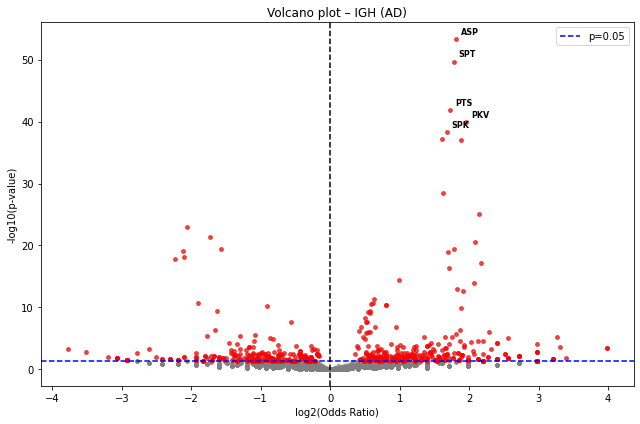

Generating volcano plot for AD - IGK


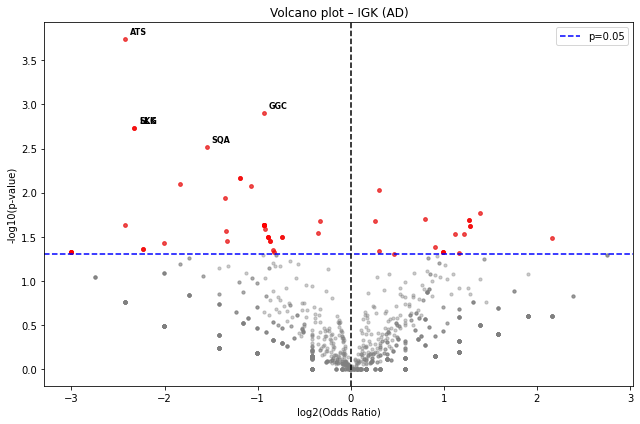

Generating volcano plot for AD - IGL


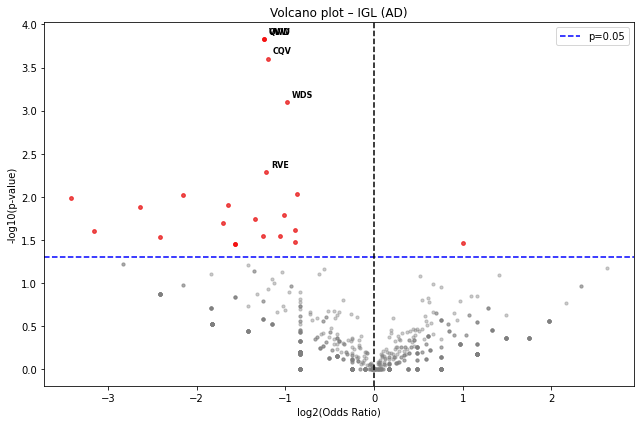

Generating volcano plot for AD - TRA


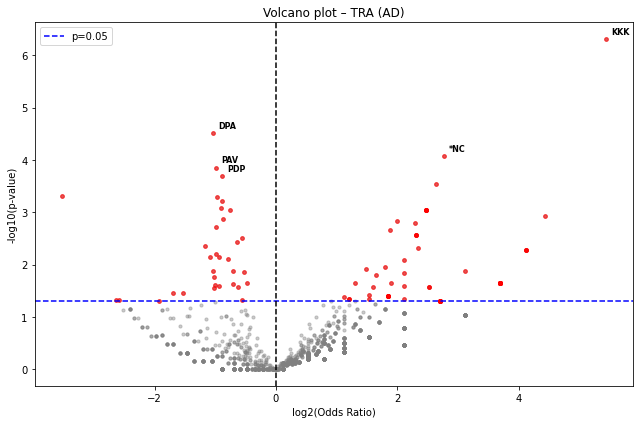

Generating volcano plot for AD - TRB


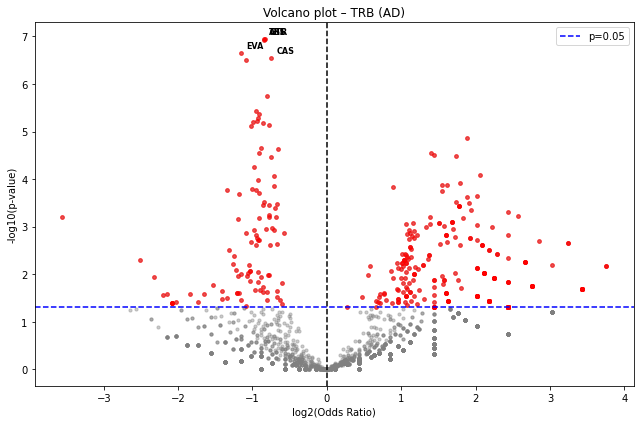

Generating volcano plot for PSO - IGH


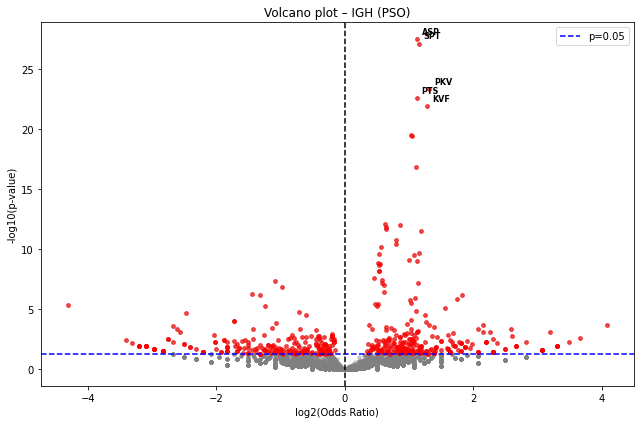

Generating volcano plot for PSO - IGK


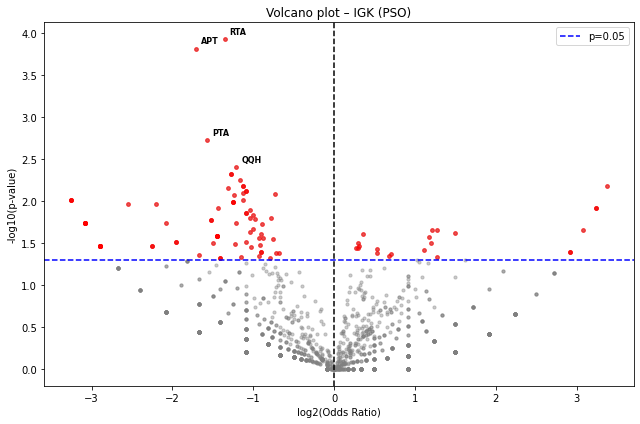

Generating volcano plot for PSO - IGL


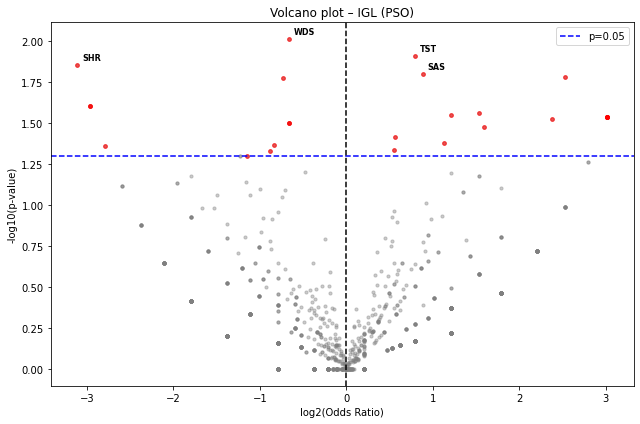

Generating volcano plot for PSO - TRA


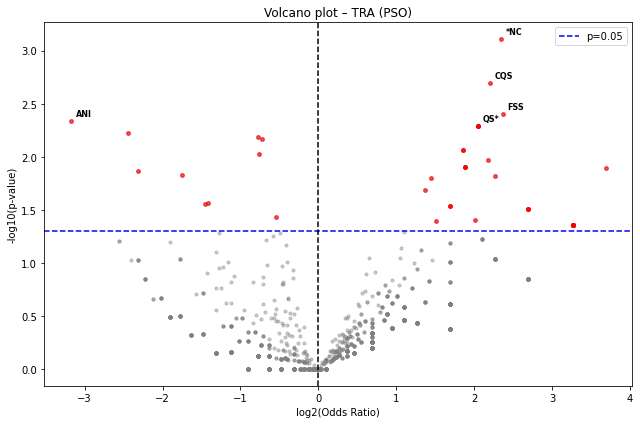

Generating volcano plot for PSO - TRB


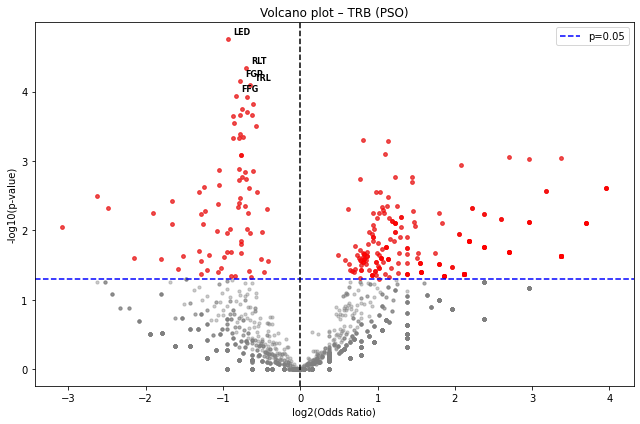


Generating scatter plot: log2OR_AD vs log2OR_PSO


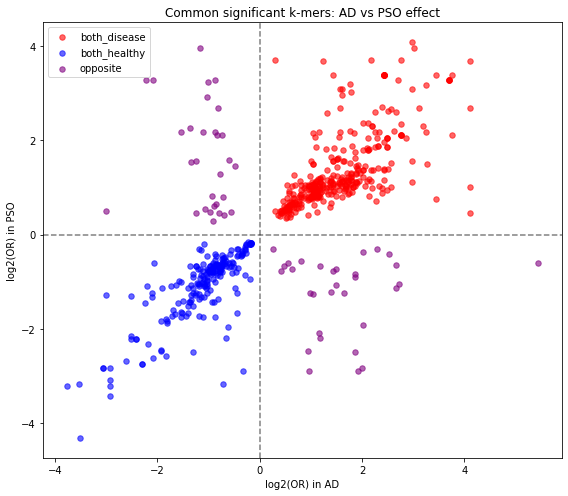


Generating bar chart: significant k-mers per locus


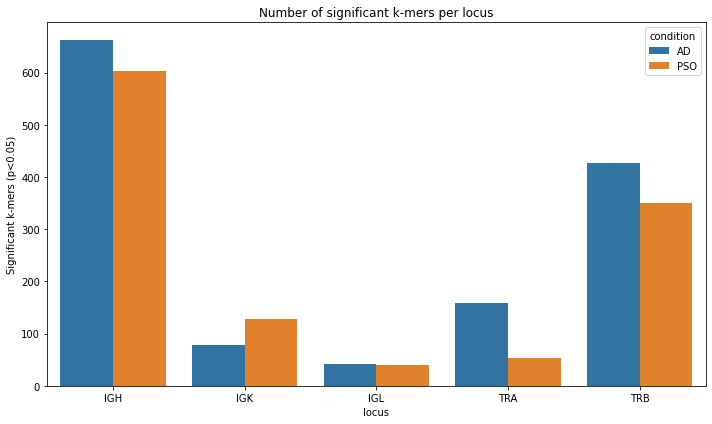


Generating origin distribution plot for AD


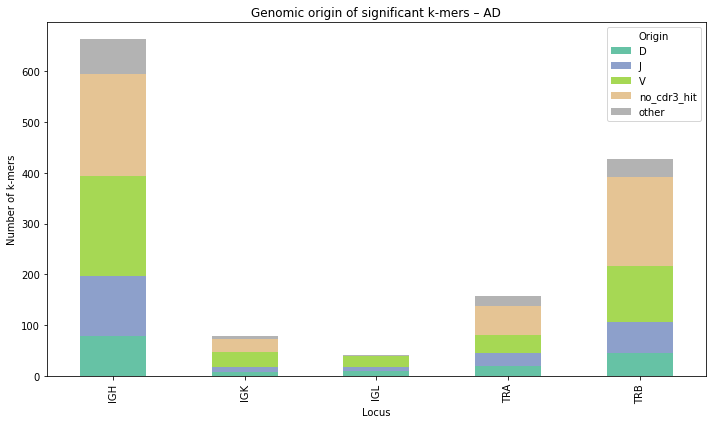


Generating origin distribution plot for PSO


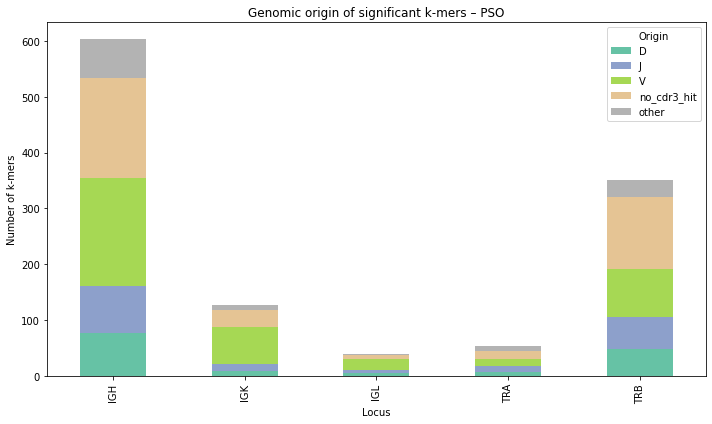


Generating CDR3 position boxplot for AD


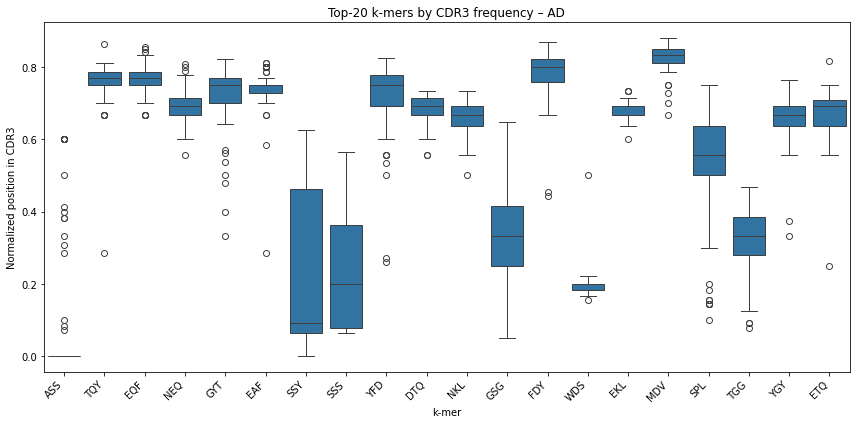


Generating CDR3 position boxplot for PSO


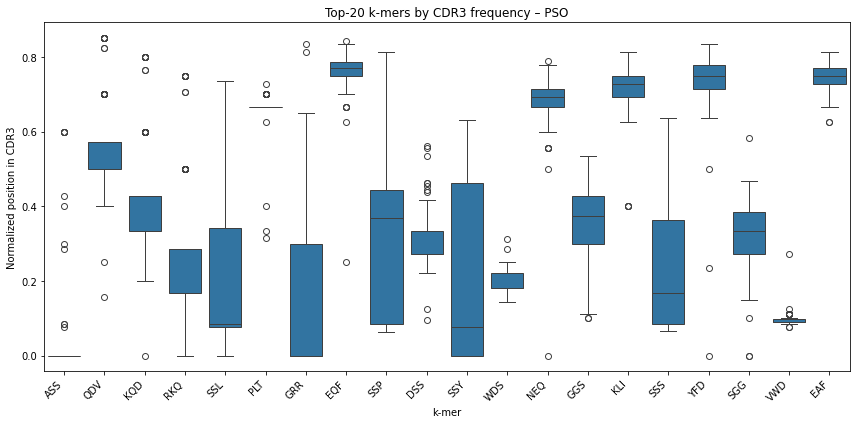


Generating heatmap for top-20 opposite-direction k-mers


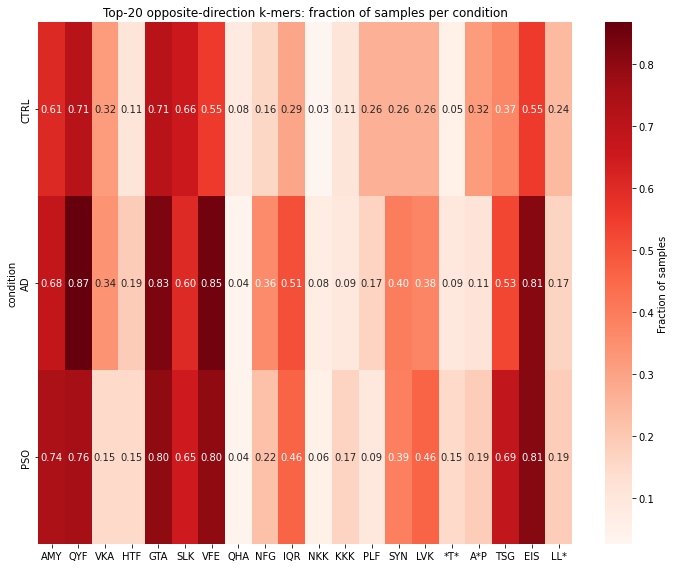


All figures saved to the 'figures' folder and displayed on screen.
Summary statistics printed above. Replace XXXX placeholders with these numbers.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# Configuration and paths
# ============================================================
os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# Load data files (adjust paths if necessary)
df_kmers = pd.read_csv("df_kmers.csv")
df_fisher_ad = pd.read_csv("fishertest/fisher_results_all_loci_pooled.csv")
df_fisher_pso = pd.read_csv("fishertest/fisher_results_all_loci_pooled_pso.csv")
df_ad_sig = pd.read_csv("summary_AD_kmers.csv")
df_pso_sig = pd.read_csv("summary_PSO_kmers.csv")
df_common = pd.read_csv("common_kmers_details.csv")

# CDR3 position files (if available)
try:
    df_cdr3_ad = pd.read_csv("cdr3/kmer_cdr3_positions_with_segments.csv")
    df_cdr3_pso = pd.read_csv("cdr3_pso/kmer_cdr3_positions_with_segments.csv")
    has_cdr3 = True
except:
    has_cdr3 = False
    print("CDR3 files not found; CDR3 position plots will be skipped.")

# ============================================================
# 1. Summary statistics (to replace XXXX in the report)
# ============================================================
print("\n===== SUMMARY STATISTICS =====")
print(f"Total productive sequences (approx): {df_kmers['sample_id'].nunique()}")
print(f"Number of unique k-mers: {df_kmers['kmer'].nunique()}")

print("\n--- Fisher tests ---")
sig_ad = df_fisher_ad[df_fisher_ad['p_value'] < 0.05]
sig_pso = df_fisher_pso[df_fisher_pso['p_value'] < 0.05]
print(f"AD: significant = {len(sig_ad)}, disease-associated (OR>1) = {sum(sig_ad['odds_ratio'] > 1)}")
print(f"PSO: significant = {len(sig_pso)}, disease-associated (OR>1) = {sum(sig_pso['odds_ratio'] > 1)}")

# By locus
for locus in df_kmers['locus'].unique():
    ad_locus = sig_ad[sig_ad['locus'] == locus]
    pso_locus = sig_pso[sig_pso['locus'] == locus]
    print(f"Locus {locus}: AD sig={len(ad_locus)} ({sum(ad_locus['odds_ratio']>1)} assoc), PSO sig={len(pso_locus)} ({sum(pso_locus['odds_ratio']>1)} assoc)")

# Common and opposite
common_kmers = set(df_ad_sig['kmer']) & set(df_pso_sig['kmer'])
same_dir = 0
opposite_dir = 0
for k in common_kmers:
    ad_assoc = df_ad_sig[df_ad_sig['kmer']==k]['association'].iloc[0]
    pso_assoc = df_pso_sig[df_pso_sig['kmer']==k]['association'].iloc[0]
    if (ad_assoc == 'AD_associated' and pso_assoc == 'PSO_associated') or \
       (ad_assoc == 'CTRL_associated' and pso_assoc == 'CTRL_associated'):
        same_dir += 1
    else:
        opposite_dir += 1
print(f"Common significant k-mers: {len(common_kmers)}")
print(f"  Same direction: {same_dir}")
print(f"  Opposite direction: {opposite_dir}")

# ============================================================
# 2. Volcano plots for AD and PSO (per locus)
# ============================================================
def volcano_plot(df_fisher, condition, suffix):
    loci = df_fisher['locus'].unique()
    for locus in loci:
        print(f"Generating volcano plot for {condition} - {locus}")
        sub = df_fisher[df_fisher['locus'] == locus].copy()
        sub['log2OR'] = np.log2(sub['odds_ratio'].replace(0, np.nan))
        sub['neg_log10_p'] = -np.log10(sub['p_value'] + 1e-300)
        sub_clean = sub.dropna(subset=['log2OR', 'neg_log10_p'])
        if sub_clean.empty:
            continue
        sig = sub_clean[sub_clean['p_value'] < 0.05]
        plt.figure(figsize=(9,6))
        plt.scatter(sub_clean['log2OR'], sub_clean['neg_log10_p'], alpha=0.4, s=10, color='gray')
        plt.scatter(sig['log2OR'], sig['neg_log10_p'], alpha=0.6, s=15, color='red')
        plt.axhline(-np.log10(0.05), linestyle='--', color='blue', label='p=0.05')
        plt.axvline(0, linestyle='--', color='black')
        plt.xlabel('log2(Odds Ratio)')
        plt.ylabel('-log10(p-value)')
        plt.title(f'Volcano plot – {locus} ({condition})')
        # Label top 5 by p-value
        top5 = sig.nsmallest(5, 'p_value')
        for _, row in top5.iterrows():
            plt.annotate(row['kmer'], xy=(row['log2OR'], row['neg_log10_p']),
                         xytext=(5,5), textcoords='offset points', fontsize=8, weight='bold')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"figures/volcano_{condition}_{locus}.png", dpi=150)
        plt.show()
        plt.close()

volcano_plot(df_fisher_ad, 'AD', 'ad')
volcano_plot(df_fisher_pso, 'PSO', 'pso')

# ============================================================
# 3. Scatter plot: log2OR_AD vs log2OR_PSO for common k-mers
# ============================================================
print("\nGenerating scatter plot: log2OR_AD vs log2OR_PSO")
df_common['log2OR_AD'] = np.log2(df_common['odds_ratio_AD'].replace(0, np.nan))
df_common['log2OR_PSO'] = np.log2(df_common['odds_ratio_PSO'].replace(0, np.nan))

def get_dir(row):
    if row['association_AD'] == 'AD_associated' and row['association_PSO'] == 'PSO_associated':
        return 'both_disease'
    elif row['association_AD'] == 'CTRL_associated' and row['association_PSO'] == 'CTRL_associated':
        return 'both_healthy'
    else:
        return 'opposite'
df_common['direction'] = df_common.apply(get_dir, axis=1)

plt.figure(figsize=(8,7))
colors = {'both_disease':'red', 'both_healthy':'blue', 'opposite':'purple'}
for dir_group, group in df_common.groupby('direction'):
    plt.scatter(group['log2OR_AD'], group['log2OR_PSO'], label=dir_group, alpha=0.6, s=30, color=colors[dir_group])
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('log2(OR) in AD')
plt.ylabel('log2(OR) in PSO')
plt.title('Common significant k-mers: AD vs PSO effect')
plt.legend()
plt.tight_layout()
plt.savefig("figures/common_kmers_scatter.png", dpi=150)
plt.show()
plt.close()

# ============================================================
# 4. Bar charts: significant k-mers per locus
# ============================================================
print("\nGenerating bar chart: significant k-mers per locus")
ad_counts = df_ad_sig.groupby('locus').size().reset_index(name='count')
ad_counts['condition'] = 'AD'
pso_counts = df_pso_sig.groupby('locus').size().reset_index(name='count')
pso_counts['condition'] = 'PSO'
both_counts = pd.concat([ad_counts, pso_counts])
plt.figure(figsize=(10,6))
sns.barplot(data=both_counts, x='locus', y='count', hue='condition')
plt.title('Number of significant k-mers per locus')
plt.ylabel('Significant k-mers (p<0.05)')
plt.tight_layout()
plt.savefig("figures/significant_kmers_per_locus.png", dpi=150)
plt.show()
plt.close()

# ============================================================
# 5. Origin distribution (stacked bar) – use df_ad_sig and df_pso_sig if they have 'origin'
# ============================================================
if 'origin' in df_ad_sig.columns:
    for df, condition in zip([df_ad_sig, df_pso_sig], ['AD', 'PSO']):
        print(f"\nGenerating origin distribution plot for {condition}")
        origin_counts = df.groupby(['locus', 'origin']).size().unstack(fill_value=0)
        if not origin_counts.empty:
            origin_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
            plt.title(f'Genomic origin of significant k-mers – {condition}')
            plt.xlabel('Locus')
            plt.ylabel('Number of k-mers')
            plt.legend(title='Origin')
            plt.tight_layout()
            plt.savefig(f"figures/origin_{condition}.png", dpi=150)
            plt.show()
            plt.close()

# ============================================================
# 6. CDR3 position boxplots (top-20 frequent k-mers)
# ============================================================
if has_cdr3:
    for df_cdr3, condition in zip([df_cdr3_ad, df_cdr3_pso], ['AD', 'PSO']):
        if df_cdr3.empty:
            continue
        print(f"\nGenerating CDR3 position boxplot for {condition}")
        top20 = df_cdr3['kmer'].value_counts().head(20).index
        sub = df_cdr3[df_cdr3['kmer'].isin(top20)]
        if sub.empty:
            continue
        plt.figure(figsize=(12,6))
        sns.boxplot(data=sub, x='kmer', y='norm_position', order=top20)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('k-mer')
        plt.ylabel('Normalized position in CDR3')
        plt.title(f'Top-20 k-mers by CDR3 frequency – {condition}')
        plt.tight_layout()
        plt.savefig(f"figures/cdr3_position_boxplot_{condition}.png", dpi=150)
        plt.show()
        plt.close()

# ============================================================
# 7. Heatmap for top-20 opposite-direction k-mers (fraction of samples)
# ============================================================
df_common['abs_log2OR'] = (df_common['log2OR_AD'].abs() + df_common['log2OR_PSO'].abs()) / 2
opposite = df_common[df_common['direction'] == 'opposite']
if not opposite.empty:
    print("\nGenerating heatmap for top-20 opposite-direction k-mers")
    top20_opp = opposite.nlargest(20, 'abs_log2OR')['kmer'].tolist()
    # Build presence matrix using crosstab
    df_presence = df_kmers[df_kmers['kmer'].isin(top20_opp)].copy()
    df_presence['present'] = 1
    presence = df_presence.pivot_table(index='sample_id', columns='kmer', values='present', fill_value=0)
    presence = presence.reset_index()
    sample_info = df_kmers[['sample_id', 'condition']].drop_duplicates()
    presence = presence.merge(sample_info, on='sample_id')
    # Compute fraction per condition
    frac = presence.groupby('condition')[top20_opp].mean()
    # Reorder to have CTRL, AD, PSO
    order = ['CTRL', 'AD', 'PSO'] if all(c in frac.index for c in ['CTRL','AD','PSO']) else frac.index
    frac = frac.reindex(order)
    plt.figure(figsize=(10,8))
    sns.heatmap(frac, annot=True, fmt='.2f', cmap='Reds', cbar_kws={'label':'Fraction of samples'})
    plt.title('Top-20 opposite-direction k-mers: fraction of samples per condition')
    plt.tight_layout()
    plt.savefig("figures/opposite_kmers_heatmap.png", dpi=150)
    plt.show()
    plt.close()
else:
    print("No opposite-direction k-mers found; skipping heatmap.")

print("\nAll figures saved to the 'figures' folder and displayed on screen.")
print("Summary statistics printed above. Replace XXXX placeholders with these numbers.")